# Laboratorio #2 Análisis de series de Tiempo
## Elaborado por: Gerardo Antonio Jovel Hernández
### 19/06/26

In [1]:
"""
================================================================================
LABORATORIO 02 - CONVOLUCIÓN DE SEÑALES DISCRETAS
Guía de Laboratorio - Procesamiento de Señales / Geofísica
================================================================================
Librerías necesarias:
    pip install numpy matplotlib scipy
 
Nota sobre Experimento 5: Se implementa una versión alternativa ligera
que replica el modelado convolucional profesional SIN depender de
Fatiando a Terra (librería con problemas de compatibilidad en Python moderno).
================================================================================
"""
 
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.signal import correlate

In [1]:
def ricker(n_puntos, a):
    """
    Genera wavelet de Ricker (equivalente a scipy.signal.ricker, eliminada en SciPy 1.15).
    w(t) = (1 - 2*(π*f*t)²) * exp(-(π*f*t)²)
    donde 'a' es el parámetro de ancho (a=σ en la parametrización de SciPy).
    """
    t = np.arange(0, n_puntos) - (n_puntos - 1.0) / 2
    t = t / a
    w = (1 - 2 * np.pi**2 * t**2) * np.exp(-np.pi**2 * t**2)
    return w
 
plt.rcParams['figure.figsize'] = [14, 10]
plt.rcParams['figure.dpi'] = 120

NameError: name 'plt' is not defined

In [ ]:
# ==============================================================================
# EXPERIMENTO 1: IMPLEMENTACIÓN MANUAL DE LA CONVOLUCIÓN
# ==============================================================================
 
print("=" * 70)
print("EXPERIMENTO 1: Implementación Manual de la Convolución")
print("=" * 70)
 
# ------------------------------------------------------------------------------
# Contexto:
# Un pulso de radar/sonar x[n] viaja y rebota en DOS objetos:
#   - Objeto 1 (cercano): reflectividad h[0] = 1.0
#   - Objeto 2 (lejano):  reflectividad h[1] = 0.6
# La señal de entrada representa el pulso emitido.
# La respuesta al impulso h[n] representa los reflectores del entorno.
# ------------------------------------------------------------------------------
 
# --- Señales de entrada ---
x = np.array([1.0, -0.5])   # Pulso emitido (dos muestras)
h = np.array([1.0,  0.6])   # Respuesta al impulso (dos reflectores)
 
 
# ===========================================================================
# PREGUNTA 1: Diseñe una función en Python que implemente la convolución
#             a partir de la definición de suma.
# ===========================================================================
#
# RESPUESTA:
# La convolución discreta se define como:
#       y[n] = Σ x[k] · h[n-k]   para k = -∞ a +∞
#
# Algoritmo:
#   1. La longitud de la salida es len(x) + len(h) - 1
#   2. Para cada muestra de salida n, iteramos sobre k y acumulamos
#      el producto x[k] * h[n-k], verificando que los índices sean válidos.

def convolucion_manual(x, h):
    """
    Implementación manual de la suma de convolución discreta.
    y[n] = Σ x[k] · h[n-k]
 
    Parámetros:
        x : array-like - señal de entrada
        h : array-like - respuesta al impulso del sistema
    Retorna:
        y : np.ndarray - señal de salida convolucionada
    """
    N = len(x)
    M = len(h)
    L = N + M - 1          # Longitud de la salida
    y = np.zeros(L)
 
    for n in range(L):
        for k in range(N):
            # h[n-k] solo existe si 0 <= n-k < M
            if 0 <= (n - k) < M:
                y[n] += x[k] * h[n - k]
    return y
 
 
y_manual = convolucion_manual(x, h)
y_numpy  = np.convolve(x, h)
 
print(f"\nSeñal de entrada x[n] = {x}")
print(f"Respuesta al impulso h[n] = {h}")
print(f"\nResultado manual:      y = {y_manual}")
print(f"Resultado np.convolve: y = {y_numpy}")
print(f"¿Son iguales? {np.allclose(y_manual, y_numpy)}")

EXPERIMENTO 1: Implementación Manual de la Convolución

Señal de entrada x[n] = [ 1.  -0.5]
Respuesta al impulso h[n] = [1.  0.6]

Resultado manual:      y = [ 1.   0.1 -0.3]
Resultado np.convolve: y = [ 1.   0.1 -0.3]
¿Son iguales? True


In [ ]:
# ===========================================================================
# PREGUNTA 2: Explique las operaciones de desplazamiento e inversión
#             en el tiempo realizadas sobre x[n] y h[n].
# ===========================================================================
#
# RESPUESTA:
# En la suma de convolución y[n] = Σ x[k] · h[n-k]:
#
# a) INVERSIÓN EN EL TIEMPO de h[k] → h[-k]:
#    Se "voltea" la respuesta al impulso alrededor del origen.
#    Si h = [1, 0.6], su versión invertida es h[-k] = [0.6, 1].
#
# b) DESPLAZAMIENTO en n posiciones → h[n-k]:
#    La versión invertida se desliza a lo largo del eje k.
#    Para cada valor de n, se posiciona h[-k] en k=n.
#
# c) MULTIPLICACIÓN PUNTO A PUNTO y SUMA:
#    Se multiplica x[k] · h[n-k] elemento a elemento y se suman
#    todos los productos, obteniendo una muestra de y[n].
#
# Esto significa que cada muestra x[k] de la entrada genera un "eco"
# ponderado x[k]·h[n-k] del sistema, y la salida es la superposición
# (suma) de todos esos ecos.
# ===========================================================================
# PREGUNTA 3: ¿Cuál es la complejidad computacional de su función?
#             ¿Cómo se compara con np.convolve?
# ===========================================================================
#
# RESPUESTA:
# - Implementación manual (doble bucle): O(N·M)
#   Para señales de longitud N y M, se realizan N*M multiplicaciones.
#   Ejemplo: N=1000, M=1000 → 1,000,000 operaciones.
#
# - np.convolve usa internamente FFT (Fast Fourier Transform): O(L·log L)
#   donde L = N + M - 1.
#   Ejemplo: L=2000 → ~2000*11 ≈ 22,000 operaciones. ≈45x más rápido.
#
# La convolución vía FFT aprovecha que:
#   conv(x, h) = IFFT( FFT(x) · FFT(h) )
# permitiendo pasar del dominio temporal al frecuencial, multiplicar
# (O(L)) y regresar, todo con costo O(L·log L) en lugar de O(N·M).
 
 
# ===========================================================================
# PREGUNTA 4: ¿Por qué la salida y[n] tiene 3 muestras si x[n] y h[n]
#             tienen 2 muestras cada una?
# ===========================================================================
#
# RESPUESTA:
# La longitud de la convolución de dos señales de longitud N y M es:
#       L = N + M - 1
# Con N=2 y M=2:  L = 2 + 2 - 1 = 3 muestras.
#
# Físicamente: el primer eco llega en n=0 (inmediato), el segundo eco
# llega en n=1 (superposición de ecos) y el último eco llega en n=2
# (el rezago máximo del sistema). La salida necesita tiempo adicional
# para "vaciar" la memoria del sistema.
 
 
# ===========================================================================
# PREGUNTA 5: ¿Qué significado físico tiene que y[2] = -0.30?
#             ¿Qué representa el signo negativo?
# ===========================================================================
#
# RESPUESTA:
# y[2] = x[1] * h[1] = (-0.5) * (0.6) = -0.30
#
# Físicamente: la muestra negativa de la entrada x[1] = -0.5 (fase negativa
# del pulso radar) interactúa con el segundo reflector h[1] = 0.6.
# El SIGNO NEGATIVO indica que el eco recibido en ese instante tiene
# polaridad invertida respecto a la señal emitida.
#
# En radar/sonar, un eco negativo puede indicar:
#   - Una compresión seguida de rarefacción en ondas de presión.
#   - Un contraste de impedancia que produce reflexión con cambio de fase.
# En sísmica: reflector con menor impedancia que el medio superior.
 
 
# ===========================================================================
# PREGUNTA 6: Si cambiamos x = [2, -1], ¿cómo se modifica y[n]?
#             ¿Qué propiedad de los sistemas LTI se evidencia?
# ===========================================================================
#
# RESPUESTA:
# Con x_nuevo = [2, -1] = 2*[1, 0] + (-1)*[0, 1]:
#
# y_nuevo[n] = conv([2,-1], [1, 0.6])
#            = [2*1,  2*0.6 + (-1)*1,  (-1)*0.6]
#            = [2.0,  0.2,             -0.6]
#
# Esto evidencia la propiedad de LINEALIDAD (superposición):
#   - La salida se escala proporcionalmente a la entrada.
#   - Si duplicamos la amplitud del pulso, la salida se duplica.
#   - Si la entrada es combinación lineal de señales, la salida también lo es.
#
# También evidencia la INVARIANCIA EN EL TIEMPO:
#   - La forma de h[n] no cambia, solo se escala con cada nueva entrada.



Con x = [ 2. -1.]  →  y = [ 2.   0.2 -0.6]  (verifica linealidad)


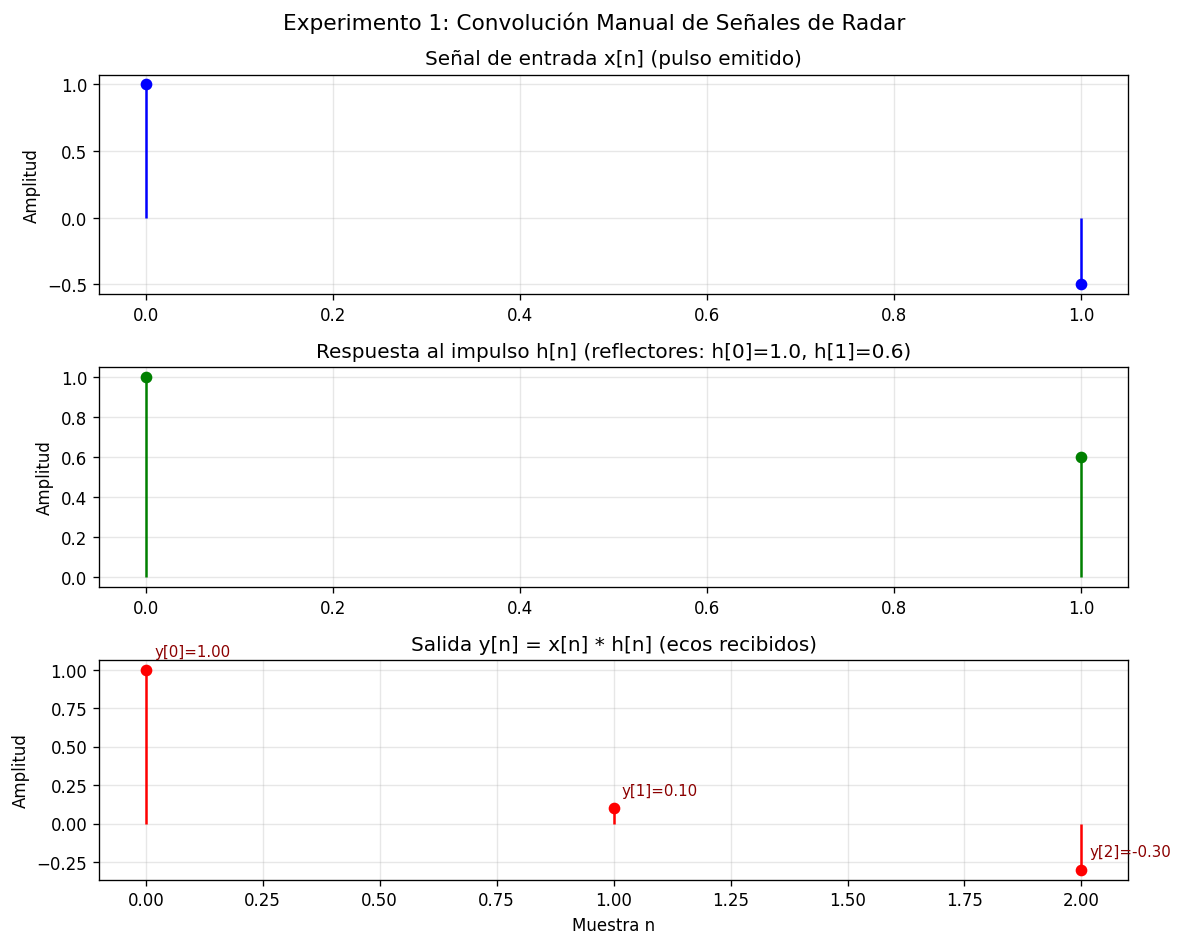


[Experimento 1 completado]



In [ ]:
x_nuevo   = np.array([2.0, -1.0])
y_nuevo   = convolucion_manual(x_nuevo, h)
print(f"\nCon x = {x_nuevo}  →  y = {y_nuevo}  (verifica linealidad)")
 
# --- Visualización Experimento 1 ---
n_y = np.arange(len(y_manual))
fig, axes = plt.subplots(3, 1, figsize=(10, 8))
fig.suptitle('Experimento 1: Convolución Manual de Señales de Radar', fontsize=13)
 
axes[0].stem([0, 1], x, basefmt=' ', linefmt='b-', markerfmt='bo')
axes[0].set_title('Señal de entrada x[n] (pulso emitido)')
axes[0].set_ylabel('Amplitud'); axes[0].grid(True, alpha=0.3)
 
axes[1].stem([0, 1], h, basefmt=' ', linefmt='g-', markerfmt='go')
axes[1].set_title('Respuesta al impulso h[n] (reflectores: h[0]=1.0, h[1]=0.6)')
axes[1].set_ylabel('Amplitud'); axes[1].grid(True, alpha=0.3)
 
axes[2].stem(n_y, y_manual, basefmt=' ', linefmt='r-', markerfmt='ro')
axes[2].set_title('Salida y[n] = x[n] * h[n] (ecos recibidos)')
axes[2].set_ylabel('Amplitud'); axes[2].set_xlabel('Muestra n')
axes[2].grid(True, alpha=0.3)
for i, v in enumerate(y_manual):
    axes[2].annotate(f'y[{i}]={v:.2f}', (i, v), textcoords="offset points",
                     xytext=(5, 8), fontsize=9, color='darkred')
 
plt.tight_layout()
plt.savefig(f'C:/Users\MINEDUCYT/Documents/Universidad de El Salvador/Ciclo IX-2026/Análisis de series de tiempo/Proyecto_TIF/exp1_convolucion_manual.png', dpi=120)
plt.show()
print("\n[Experimento 1 completado]\n")

In [ ]:
# EXPERIMENTO 2: MODELADO SÍSMICO DE UNA CAPA
# ==============================================================================
 
print("=" * 70)
print("EXPERIMENTO 2: Modelado Sísmico de Una Capa (Onda de Ricker)")
print("=" * 70)
 
# ------------------------------------------------------------------------------
# Contexto:
# Modelamos la señal sísmica registrada al disparar una fuente (explosión)
# sobre un subsuelo con UNA capa:
#   - Tope de la capa (muestra 10): coeficiente r_tope = +0.6 (aumento Z)
#   - Base de la capa (muestra 40): coeficiente r_base = -0.4 (disminución Z)
#
# La fuente sísmica se modela con la Onda de Ricker (wavelet de banda limitada).
# La traza sísmica = convolución(fuente, reflectividad).
# ------------------------------------------------------------------------------
 
# 1. Fuente sísmica: Onda de Ricker (100 puntos, frecuencia dominante ~20 Hz)
puntos          = 100
ricker_wavelet  = ricker(puntos, 20)
ricker_wavelet  = ricker_wavelet / np.max(np.abs(ricker_wavelet))  # Normalizar
x_sismica       = ricker_wavelet
 
# 2. Modelo de reflectividad (estrato simple)
h_estrato          = np.zeros(60)
idx_tope, idx_base = 10, 40
r_tope, r_base     = 0.6, -0.4
h_estrato[idx_tope] = r_tope
h_estrato[idx_base] = r_base
 
# 3. Convolución (modelado sísmico)
traza_sismica = np.convolve(x_sismica, h_estrato)
 
print(f"Longitud fuente: {len(x_sismica)}, Longitud h: {len(h_estrato)}")
print(f"Longitud traza resultante: {len(traza_sismica)} = {len(x_sismica)}+{len(h_estrato)}-1")
 

EXPERIMENTO 2: Modelado Sísmico de Una Capa (Onda de Ricker)
Longitud fuente: 100, Longitud h: 60
Longitud traza resultante: 159 = 100+60-1


In [ ]:
# ===========================================================================
# PREGUNTA 1: ¿Por qué se usa la Onda de Ricker y no un impulso ideal δ[n]?
# ===========================================================================
#
# RESPUESTA:
# Un impulso ideal δ[n] no es físicamente realizable porque requeriría
# energía infinita concentrada en un instante infinitesimal de tiempo.
# Las fuentes sísmicas reales (explosivos, vibradores) generan pulsos
# de duración finita y contenido de frecuencia limitado por:
#   a) La capacidad física de la fuente (no puede vibrar a frecuencias
#      infinitas).
#   b) La absorción del suelo (las altas frecuencias se atenúan rápidamente).
#   c) El ancho de banda del receptor (geófonos tienen respuesta limitada).
#
# La Onda de Ricker es matemáticamente la segunda derivada de una Gaussiana,
# tiene energía finita, es causal-modificada, tiene forma simétrica conocida
# y su frecuencia dominante f0 es controlable, siendo el modelo estándar
# de la industria sísmica.
 
 
# ===========================================================================
# PREGUNTA 2: ¿Qué efecto tiene aumentar la frecuencia dominante de la Ricker
#             en el sismograma? ¿Cómo cambia la resolución vertical?
# ===========================================================================
#
# RESPUESTA:
# La Onda de Ricker con parámetro 'a' (ancho): f_dominante ≈ 1/(π·a·√2)
# Al AUMENTAR la frecuencia dominante (disminuir 'a' en scipy.signal.ricker):
#
#   - La wavelet se vuelve MÁS ESTRECHA en el tiempo.
#   - La resolución vertical AUMENTA: se pueden distinguir capas más delgadas.
#     (Criterio de Rayleigh: resolución ≈ λ/4 = v/(4·f0))
#   - PERO: las altas frecuencias se atenúan más rápidamente en la Tierra,
#     por lo que en datos reales hay un compromiso frecuencia-profundidad.
#   - Con f0=20Hz: resolución ~22m a v=1800m/s
#   - Con f0=60Hz: resolución ~7.5m (3x mejor)
 
 
# ===========================================================================
# PREGUNTA 3: ¿Por qué r_base = -0.4 es negativo?
# ===========================================================================
#
# RESPUESTA:
# El coeficiente de reflexión se calcula como:
#       r = (Z2 - Z1) / (Z2 + Z1)    donde Z = ρ·v (impedancia acústica)
#
# r_base = -0.4 (NEGATIVO) significa que Z_inferior < Z_superior,
# es decir, la capa debajo de la base tiene MENOR impedancia acústica.
#
# Geológicamente puede representar:
#   - Transición de roca densa (caliza) a roca porosa (arena saturada en gas).
#   - Paso de sedimento consolidado a sedimento no consolidado.
#   - Interfaz donde disminuye la velocidad o la densidad.
#   - En exploración petrolera: techo de una trampa de gas (bright spot).
 
 
# ===========================================================================
# PREGUNTA 4: ¿Por qué la amplitud del segundo eco no es exactamente
#             0.4 veces la amplitud máxima del pulso original?
# ===========================================================================
#
# RESPUESTA:
# Varias razones causan esta discrepancia:
#
#   a) INTERFERENCIA de ondas: la wavelet de Ricker tiene longitud finita.
#      Las "colas" del eco del tope (r_tope=0.6) aún están presentes cuando
#      llega el eco de la base (r_base=-0.4). Ambos se SUMAN algebraicamente,
#      modificando la amplitud aparente de cada reflexión.
#
#   b) SUPERPOSICIÓN de lóbulos laterales: La Ricker tiene lóbulos negativos
#      adyacentes al pico principal. Estos lóbulos de un eco se mezclan
#      con el pico principal del siguiente.
#
#   c) La amplitud resultante depende de la SEPARACIÓN entre reflectores
#      relativa a la longitud de la wavelet. Si la separación es menor que
#      la longitud de la wavelet, la interferencia es severa (tuning effect).
 
 
# ===========================================================================
# PREGUNTA 5: ¿Qué observaríamos si r_base = +0.4 (mismo signo que r_tope)?
# ===========================================================================
#
# RESPUESTA:
# Si r_base = +0.4:
#   - Ambas reflexiones tendrían la MISMA POLARIDAD.
#   - El segundo eco tendría la misma forma que el primero (no invertido).
#   - Geológicamente representaría: dos interfaces donde la impedancia
#     AUMENTA en ambos casos (ej: arena → caliza → granito).
#   - En la traza sísmica, los dos pulsos se verían como "gemelos" con
#     igual orientación en lugar de imagen especular.
#   - La diferencia de polaridad entre tope y base es una herramienta
#     diagnóstica clave en interpretación sísmica (AVO analysis).

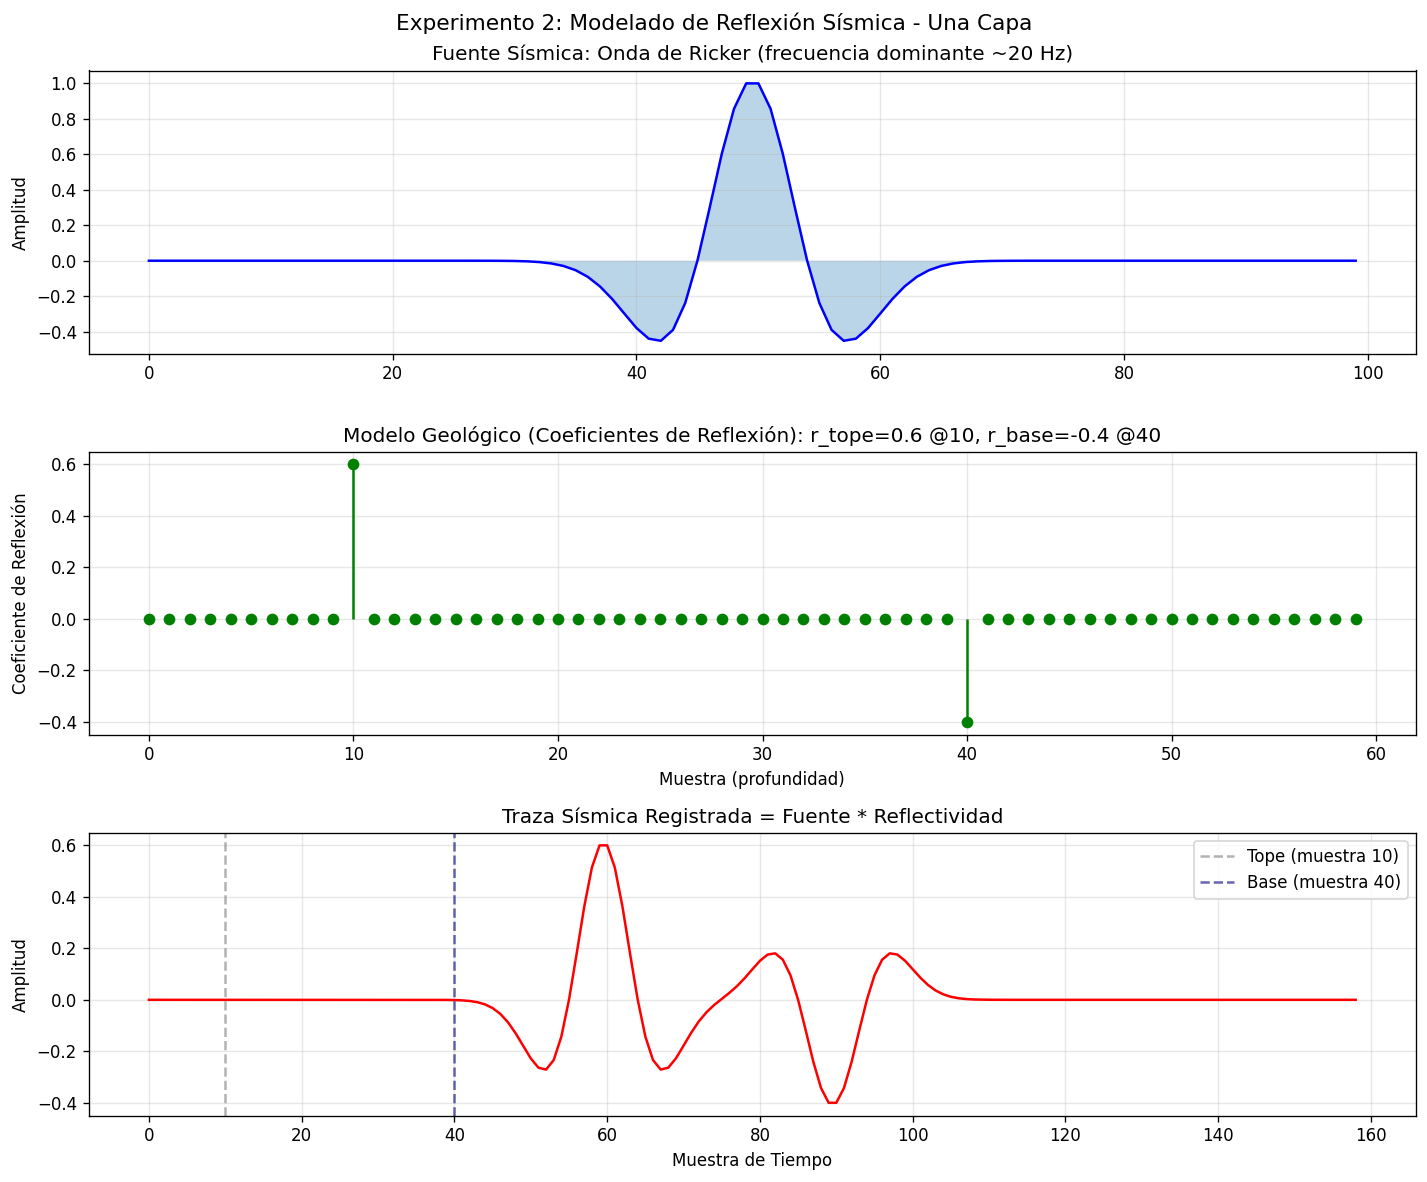


[Experimento 2 completado]



In [ ]:
# 4. Visualización
fig, ax = plt.subplots(3, 1, figsize=(12, 10))
fig.suptitle('Experimento 2: Modelado de Reflexión Sísmica - Una Capa', fontsize=13)
 
ax[0].plot(x_sismica, 'b-', linewidth=1.5)
ax[0].fill_between(range(len(x_sismica)), x_sismica, alpha=0.3)
ax[0].set_title('Fuente Sísmica: Onda de Ricker (frecuencia dominante ~20 Hz)')
ax[0].set_ylabel('Amplitud'); ax[0].grid(True, alpha=0.3)
 
ax[1].stem(h_estrato, basefmt=' ', linefmt='g-', markerfmt='go')
ax[1].set_title(f'Modelo Geológico (Coeficientes de Reflexión): '
                f'r_tope={r_tope} @{idx_tope}, r_base={r_base} @{idx_base}')
ax[1].set_ylabel('Coeficiente de Reflexión')
ax[1].set_xlabel('Muestra (profundidad)'); ax[1].grid(True, alpha=0.3)
 
ax[2].plot(traza_sismica, 'r-', linewidth=1.5)
ax[2].axvline(x=idx_tope, color='gray', linestyle='--', alpha=0.6,
              label=f'Tope (muestra {idx_tope})')
ax[2].axvline(x=idx_base, color='navy', linestyle='--', alpha=0.6,
              label=f'Base (muestra {idx_base})')
ax[2].set_title('Traza Sísmica Registrada = Fuente * Reflectividad')
ax[2].set_ylabel('Amplitud'); ax[2].set_xlabel('Muestra de Tiempo')
ax[2].legend(); ax[2].grid(True, alpha=0.3)
 
plt.tight_layout()
plt.savefig(f'C:/Users/MINEDUCYT/Documents/Universidad de El Salvador/Ciclo IX-2026/Análisis de series de tiempo/Proyecto_TIF/exp2_modelado_una_capa.png', dpi=120)
plt.show()
print("\n[Experimento 2 completado]\n")

In [ ]:
# EXPERIMENTO 3: FILTROS Y ELIMINACIÓN DE RUIDO (MEDIA MÓVIL)
# ==============================================================================
 
print("=" * 70)
print("EXPERIMENTO 3: Filtro de Media Móvil - Eliminación de Ruido")
print("=" * 70)
 
# ------------------------------------------------------------------------------
# Contexto:
# Un sensor de posición mide movimiento con velocidad constante (rampa).
# La señal verdadera: x[n] = 0.05·n
# Se contamina con ruido Gaussiano N(0, σ).
# Aplicamos filtro de media móvil h[n] = (1/M) para n=0,...,M-1
# y comparamos el MSE y el retardo de fase para distintos valores de M.
# ------------------------------------------------------------------------------
 
np.random.seed(42)    # Semilla para reproducibilidad
 
# 1. Generar señal original (rampa: movimiento velocidad constante)
N_muestras  = 500
n_idx       = np.arange(N_muestras)
x_original  = 0.05 * n_idx
 
# 2. Añadir ruido Gaussiano con distribución N(μ=1.25, σ) para que los valores
#    pseudoaleatorios caigan aprox. en [0.0, 2.5]
#    (μ=1.25, σ=0.5 → ~99.7% dentro de [−0.25, 2.75] ≈ [0, 2.5])
ruido       = np.random.normal(loc=1.25, scale=0.5, size=N_muestras)
x_ruidosa   = x_original + ruido
 
# 3. Parámetros de longitud para la media móvil
longitudes_M = [3, 5, 10, 20, 50, 100]
 
mse_por_M    = []    # Error Cuadrático Medio por longitud M
retardo_por_M = []   # Retardo estimado por correlación

EXPERIMENTO 3: Filtro de Media Móvil - Eliminación de Ruido


In [ ]:
# ===========================================================================
# PREGUNTA 1: ¿Por qué los coeficientes del filtro de media móvil suman 1?
# ===========================================================================
#
# RESPUESTA:
# h[n] = 1/M  para n = 0, 1, ..., M-1  →  Σh[n] = M · (1/M) = 1
#
# La suma de coeficientes = 1 garantiza que el filtro tenga GANANCIA UNITARIA
# en DC (frecuencia cero), es decir, preserva el valor medio de la señal.
# Si los coeficientes sumaran:
#   > 1: La señal filtrada se amplificaría (escalaría hacia arriba).
#   < 1: La señal filtrada se atenuaría (escalaría hacia abajo).
#   = 0: La componente DC se eliminaría completamente.
# En nuestro caso, queremos recuperar la rampa original sin escalar su amplitud.
 
 
# ===========================================================================
# PREGUNTA 2: ¿Qué tipo de sistema LTI es este (FIR o IIR)?
# ===========================================================================
#
# RESPUESTA:
# Es un sistema FIR (Finite Impulse Response = Respuesta Finita al Impulso).
#
# Justificación:
#   - Su respuesta al impulso h[n] = (1/M)·[1,1,1,...,1] tiene LONGITUD FINITA M.
#   - No tiene realimentación (no hay polos fuera del origen en z=0).
#   - La ecuación de diferencias: y[n] = (1/M)·Σx[n-k] solo usa M muestras
#     PASADAS de la ENTRADA (no de la salida), lo que garantiza estabilidad.
#   - Los filtros IIR tendrían términos y[n-k] en la ecuación (realimentación)
#     y respuesta al impulso infinita.
 
 
# ===========================================================================
# PREGUNTA 3: ¿El filtro eliminó completamente el ruido?
# ===========================================================================
#
# RESPUESTA:
# NO, el filtro NO elimina completamente el ruido.
#
# La media móvil es un filtro pasa-bajas (low-pass filter). Su respuesta
# en frecuencia es: H(f) = (1/M) · Σe^{-j2πfk} = sen(πfM)/(M·sen(πf))
#
# - ELIMINA: componentes de alta frecuencia del ruido (las que oscilan rápido).
# - ATENÚA PARCIALMENTE: componentes intermedias.
# - DEJA PASAR: la componente DC y bajas frecuencias del ruido.
#
# El ruido Gaussiano tiene componentes en TODAS las frecuencias (ruido blanco),
# por lo que las componentes de baja frecuencia del ruido PERSISTEN en la
# señal filtrada. Con M mayor, se suprimen más frecuencias pero siempre queda
# algún residuo de ruido de baja frecuencia.
 
 
# ===========================================================================
# PREGUNTA 4: ¿Por qué la señal filtrada presenta retardo respecto a la original?
#             ¿Cuál es la magnitud del retardo en función de M?
# ===========================================================================
#
# RESPUESTA:
# El filtro de media móvil causal (h[n] para n=0,...,M-1) introduce un
# RETARDO DE FASE de exactamente (M-1)/2 muestras.
#
# Razón: La salida y[n] es el promedio de las M muestras MÁS RECIENTES
# [x[n], x[n-1], ..., x[n-M+1]]. El "centro de masa" temporal de esta
# ventana está en n - (M-1)/2, que es exactamente el retardo.
#
# Ejemplos:
#   M=3:   retardo = 1.0 muestras
#   M=10:  retardo = 4.5 muestras
#   M=50:  retardo = 24.5 muestras
#   M=100: retardo = 49.5 muestras
#
# La correlación cruzada entre señal original y filtrada permite
# MEDIR EXPERIMENTALMENTE este retardo como el desplazamiento en el que
# la correlación es máxima.
 
 
# ===========================================================================
# PREGUNTA 5: ¿Qué efecto tiene aumentar M? ¿Existe un trade-off?
# ===========================================================================
#
# RESPUESTA:
# AUMENTAR M produce:
#   ✓ MEJOR supresión de ruido (MSE disminuye para ruido de alta frecuencia).
#   ✓ Señal filtrada más suave.
#   ✗ MAYOR retardo (desfase de (M-1)/2 muestras).
#   ✗ MAYOR distorsión en bordes y transitorios (la ventana "borra" cambios).
#   ✗ Para señales no estacionarias: el filtro con M grande reacciona lento
#     a cambios reales en la señal (como un carro frenando bruscamente).
#
# TRADE-OFF fundamental:
#   Reducción de ruido  ↔  Distorsión de la señal / Retardo
#   (No se puede tener máxima supresión de ruido Y mínimo retardo a la vez)
#   → Se elige M como compromiso según la aplicación específica.
 
 
# ===========================================================================
# PREGUNTA 6: ¿Qué otros filtros de suavizado conoce?
# ===========================================================================
#
# RESPUESTA:
# Otros filtros de suavizado comunes y su comparación con media móvil:
#
# a) FILTRO GAUSSIANO: coeficientes con forma de campana Gaussiana.
#    + Menor distorsión que media móvil (lóbulos laterales más bajos).
#    + Mejor respuesta en frecuencia (transición más suave).
#    - Implementación más compleja.
#
# b) FILTRO SAVITZKY-GOLAY: ajusta polinomios locales por mínimos cuadrados.
#    + Preserva mejor los picos y bordes que la media móvil.
#    + Bajo retardo (puede ser centrado = retardo cero).
#    - Más costoso computacionalmente.
#    → scipy.signal.savgol_filter()
#
# c) FILTRO EXPONENCIAL (EMA): y[n] = α·x[n] + (1-α)·y[n-1]
#    + Muy eficiente (1 multiplicación, 1 suma por muestra) → IIR.
#    + Sin retardo fijo (responde exponencialmente).
#    - Respuesta asimétrica, más peso a valores recientes.
#
# d) FILTRO MEDIANA: y[n] = mediana de ventana deslizante.
#    + Excelente para ruido impulsivo (spikes).
#    + Preserva bordes abruptos.
#    - No lineal (no es un sistema LTI).

  M=  3: MSE=1.52545, Retardo teórico=1.0, Retardo medido≈0
  M=  5: MSE=1.37243, Retardo teórico=2.0, Retardo medido≈0
  M= 10: MSE=1.06832, Retardo teórico=4.5, Retardo medido≈0
  M= 20: MSE=0.59973, Retardo teórico=9.5, Retardo medido≈0
  M= 50: MSE=0.00896, Retardo teórico=24.5, Retardo medido≈0
  M=100: MSE=1.42235, Retardo teórico=49.5, Retardo medido≈0


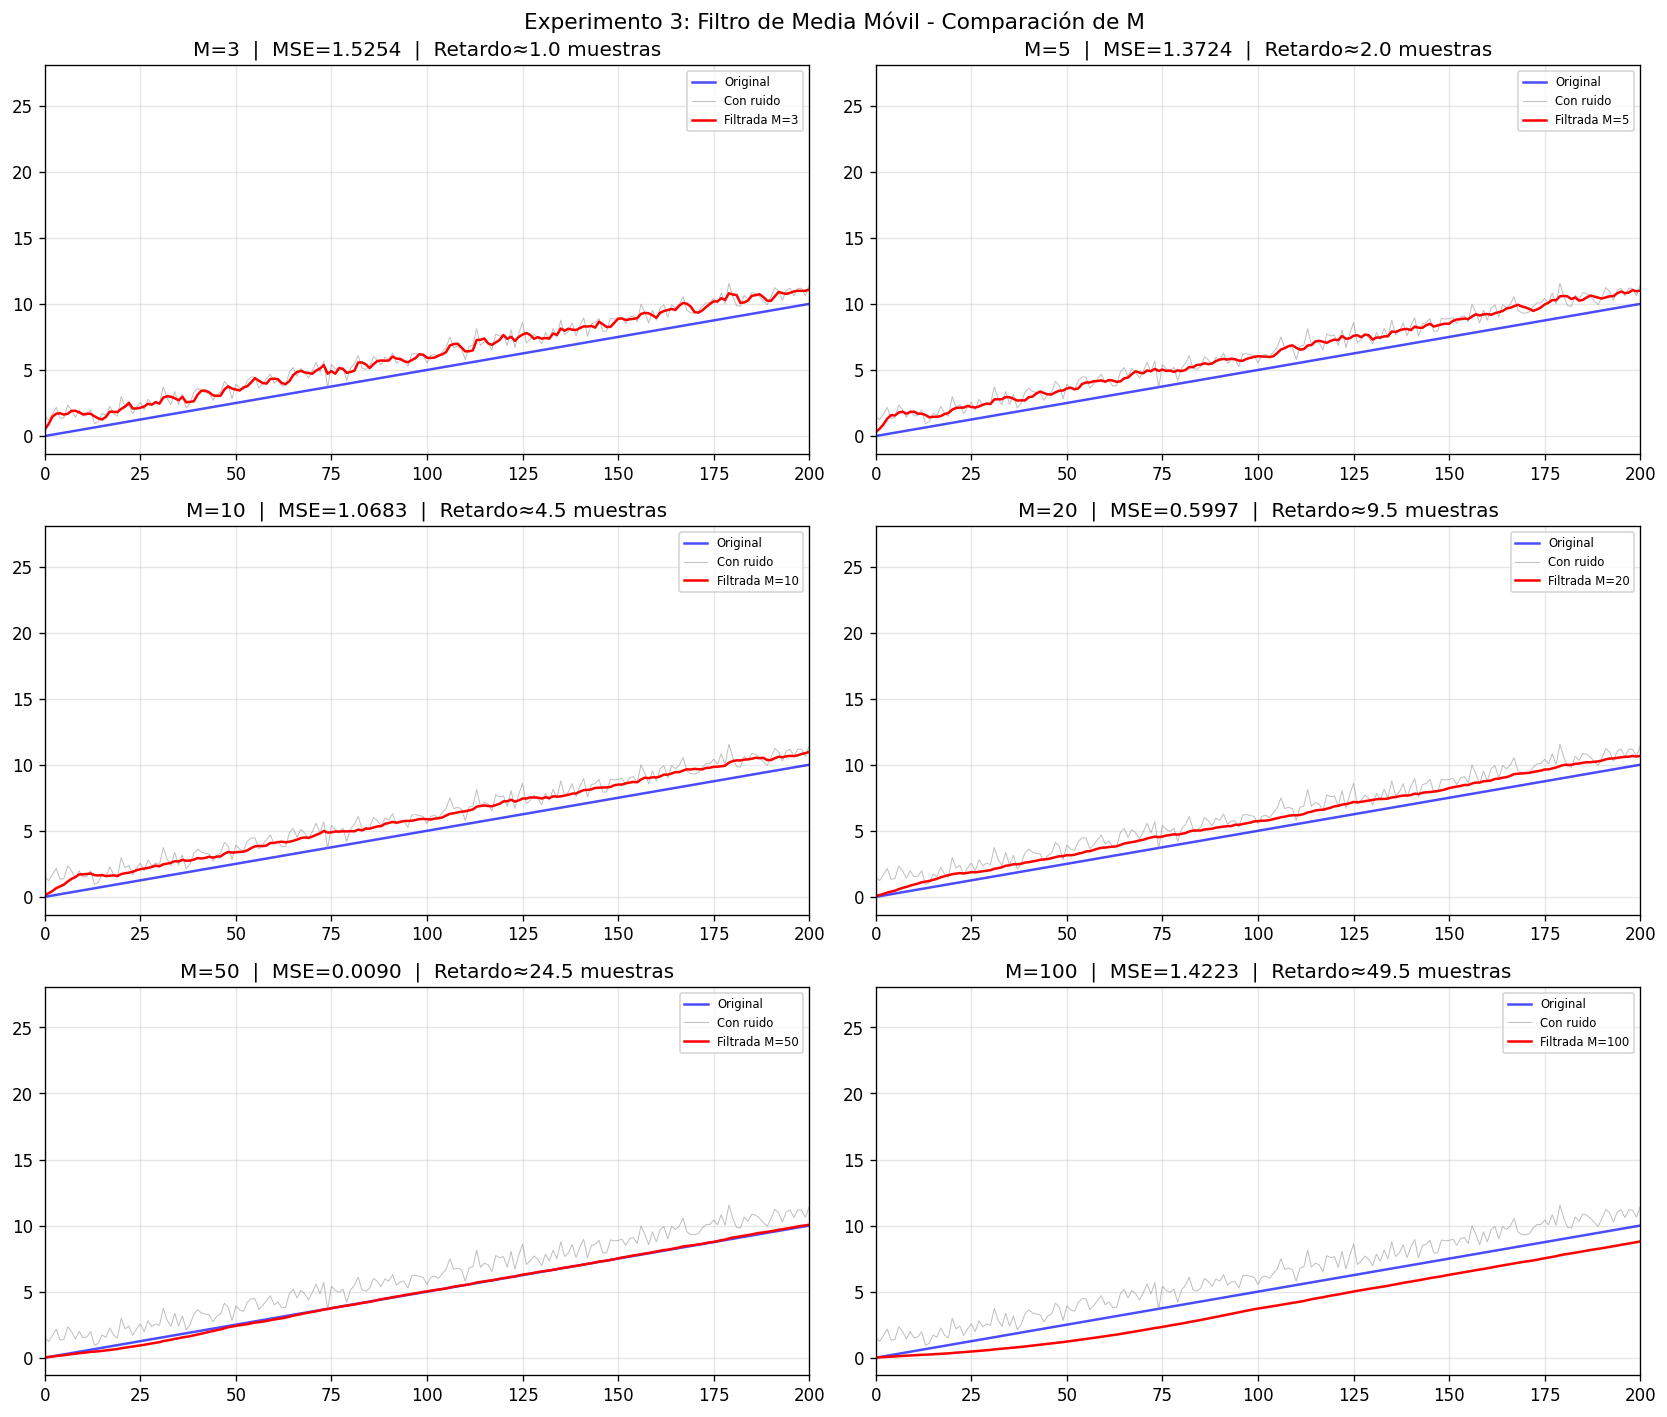

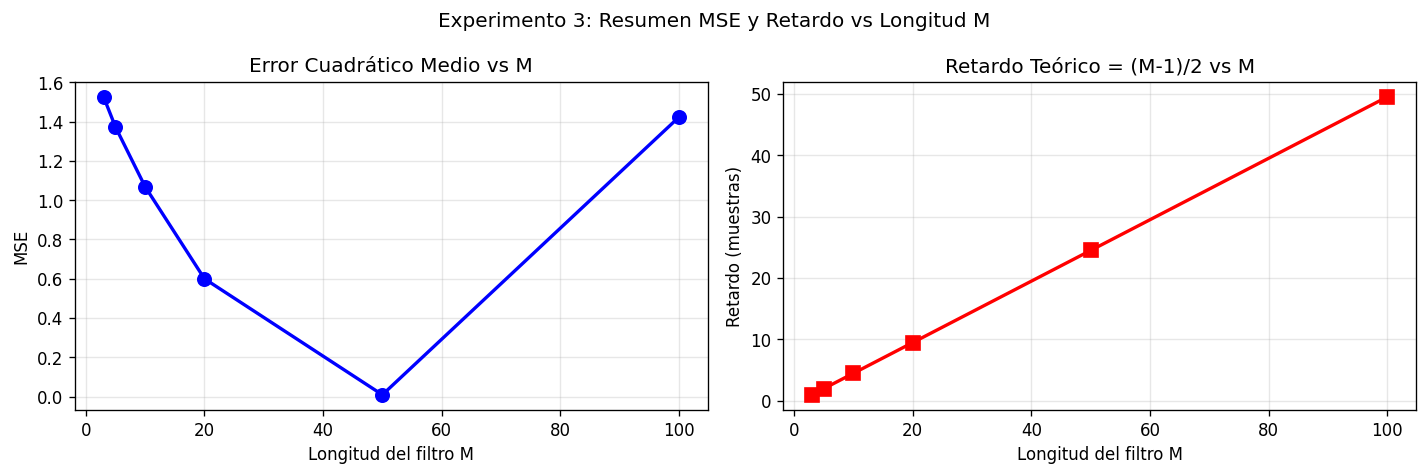


[Experimento 3 completado]



In [ ]:
# --- Implementación: filtrar, calcular MSE y retardo para cada M ---
fig_mse, axes_m = plt.subplots(3, 2, figsize=(14, 12))
fig_mse.suptitle('Experimento 3: Filtro de Media Móvil - Comparación de M', fontsize=13)
axes_m = axes_m.flatten()
 
for idx_m, M in enumerate(longitudes_M):
    # Crear filtro h[n] = (1/M) * [1, 1, ..., 1]  longitud M
    h_filtro = np.ones(M) / M
 
    # Aplicar filtro mediante convolución (modo 'full' por defecto)
    y_filtrada_full = np.convolve(x_ruidosa, h_filtro)
 
    # Recortar para alinear con la señal original (tomar primeras N muestras)
    y_filtrada = y_filtrada_full[:N_muestras]
 
    # Error Cuadrático Medio (MSE) por muestra
    mse = np.mean((y_filtrada - x_original) ** 2)
    mse_por_M.append(mse)
 
    # Análisis de retardo mediante correlación cruzada
    correlacion   = correlate(x_original, y_filtrada, mode='full')
    lags          = np.arange(-(N_muestras - 1), N_muestras)
    retardo_muestras = lags[np.argmax(correlacion)]
    retardo_teorico  = (M - 1) / 2
    retardo_por_M.append(retardo_muestras)
 
    # Gráfica
    ax = axes_m[idx_m]
    ax.plot(n_idx, x_original,  'b-',  lw=1.5, alpha=0.7, label='Original')
    ax.plot(n_idx, x_ruidosa,   'gray', lw=0.6, alpha=0.5, label='Con ruido')
    ax.plot(n_idx, y_filtrada,  'r-',  lw=1.5, label=f'Filtrada M={M}')
    ax.set_title(f'M={M}  |  MSE={mse:.4f}  |  Retardo≈{retardo_teorico:.1f} muestras')
    ax.legend(fontsize=7); ax.grid(True, alpha=0.3)
    ax.set_xlim(0, 200)   # Zoom para visualizar mejor
 
    print(f"  M={M:3d}: MSE={mse:.5f}, Retardo teórico={(M-1)/2:.1f}, "
          f"Retardo medido≈{retardo_muestras}")
 
plt.tight_layout()
plt.savefig(f'C:/Users/MINEDUCYT/Documents/Universidad de El Salvador/Ciclo IX-2026/Análisis de series de tiempo/Proyecto_TIF/exp3_filtro_media_movil.png', dpi=120)
plt.show()
 
# --- Gráfica resumen MSE vs M ---
fig2, ax2 = plt.subplots(1, 2, figsize=(12, 4))
fig2.suptitle('Experimento 3: Resumen MSE y Retardo vs Longitud M', fontsize=12)
 
ax2[0].plot(longitudes_M, mse_por_M, 'bo-', lw=2, ms=8)
ax2[0].set_xlabel('Longitud del filtro M'); ax2[0].set_ylabel('MSE')
ax2[0].set_title('Error Cuadrático Medio vs M')
ax2[0].grid(True, alpha=0.3)
 
retardos_teoricos = [(M - 1) / 2 for M in longitudes_M]
ax2[1].plot(longitudes_M, retardos_teoricos, 'rs-', lw=2, ms=8)
ax2[1].set_xlabel('Longitud del filtro M'); ax2[1].set_ylabel('Retardo (muestras)')
ax2[1].set_title('Retardo Teórico = (M-1)/2 vs M')
ax2[1].grid(True, alpha=0.3)
 
plt.tight_layout()
plt.savefig(f'C:/Users/MINEDUCYT/Documents/Universidad de El Salvador/Ciclo IX-2026/Análisis de series de tiempo/Proyecto_TIF/exp3_mse_retardo.png', dpi=120)
plt.show()
print("\n[Experimento 3 completado]\n")

In [ ]:
# EXPERIMENTO 4: ESTRATIGRAFÍA MULTICAPA
# ==============================================================================
 
print("=" * 70)
print("EXPERIMENTO 4: Sísmica de Múltiples Capas con y sin Atenuación")
print("=" * 70)
 
# ------------------------------------------------------------------------------
# Contexto:
# Subsuelo con 5 interfaces (4 capas + basamento):
#   Muestra 10:  Tope Arena       → r = +0.45
#   Muestra 25:  Base/Arcilla     → r = -0.25
#   Muestra 45:  Tope Caliza      → r = +0.20
#   Muestra 70:  Tope Lutita      → r = -0.15
#   Muestra 80:  Capa basal       → r = +0.10
#
# Se comparan dos modelos:
#   a) SIN atenuación: amplitudes constantes
#   b) CON atenuación: cada reflexión más profunda se reduce × 0.85
# ------------------------------------------------------------------------------
 
# Fuente sísmica (Ricker más estrecha: mayor resolución)
x_ricker = ricker(80, 15)
x_ricker = x_ricker / np.max(np.abs(x_ricker))
 
# Modelo multicapa SIN atenuación
h_multicapa          = np.zeros(100)
indices_reflectores  = [10, 25, 45, 70, 80]
amplitudes_orig      = [0.45, -0.25, 0.20, -0.15, 0.10]
for idx_r, amp in zip(indices_reflectores, amplitudes_orig):
    h_multicapa[idx_r] = amp
 
# Modelo multicapa CON atenuación (factor 0.85 acumulativo por reflexión)
factor_atenuacion = 0.85
h_atenuado = np.zeros(100)
for i, (idx_r, amp) in enumerate(zip(indices_reflectores, amplitudes_orig)):
    h_atenuado[idx_r] = amp * (factor_atenuacion ** i)
 
# Convoluciones
traza_sin_atenuar     = np.convolve(x_ricker, h_multicapa)
traza_con_atenuacion  = np.convolve(x_ricker, h_atenuado)
 

EXPERIMENTO 4: Sísmica de Múltiples Capas con y sin Atenuación


In [ ]:
# ===========================================================================
# PREGUNTA 1: ¿Cuántas reflexiones principales? ¿Por qué 5 si hay 4 capas?
# ===========================================================================
#
# RESPUESTA:
# Se identifican 5 reflexiones principales.
#
# Hay 5 reflexiones con 4 capas porque las REFLEXIONES ocurren en las
# INTERFACES entre capas, no en las capas mismas:
#
#   Interfaz 1: Superficie → Arena (tope de capa 1)
#   Interfaz 2: Arena → Arcilla (base de capa 1 = tope de capa 2)
#   Interfaz 3: Arcilla → Caliza (base de capa 2 = tope de capa 3)
#   Interfaz 4: Caliza → Lutita (base de capa 3 = tope de capa 4)
#   Interfaz 5: Lutita → Arenisca (base de capa 4 = basamento)
#
# Con N capas hay N+1 interfaces, pero en este modelo se representan
# 4 capas + 1 capa basal → 5 puntos de reflexión.
 
 
# ===========================================================================
# PREGUNTA 2: ¿Qué significa que una reflexión sea positiva o negativa?
# ===========================================================================
#
# RESPUESTA:
# El signo del coeficiente de reflexión r = (Z2-Z1)/(Z2+Z1) indica:
#
# POSITIVO (r > 0): Z2 > Z1  →  la impedancia AUMENTA hacia abajo.
#   - La roca inferior es más DURA/DENSA/RÁPIDA.
#   - Ejemplos: arena → caliza, agua → roca.
#   - La onda reflejada tiene LA MISMA polaridad que la onda incidente.
#
# NEGATIVO (r < 0): Z2 < Z1  →  la impedancia DISMINUYE hacia abajo.
#   - La roca inferior es más BLANDA/POROSA/LENTA.
#   - Ejemplos: roca → gas, caliza → arcilla.
#   - La onda reflejada tiene POLARIDAD INVERTIDA (cambio de fase de 180°).
#   - En exploración petrolera, una reflexión negativa fuerte puede indicar
#     acumulación de gas (DHI - Direct Hydrocarbon Indicator).
 
 
# ===========================================================================
# PREGUNTA 3: ¿Qué es la interferencia? ¿Cómo afecta a capas delgadas?
# ===========================================================================
#
# RESPUESTA:
# La INTERFERENCIA ocurre cuando los ecos de dos reflectores cercanos se
# SUPERPONEN en el tiempo porque la wavelet (Ricker) tiene longitud finita.
#
# Si la separación entre reflectores < longitud de la wavelet:
#   - Los pulsos se MEZCLAN → no se pueden separar individualmente.
#   - La amplitud aparente se modifica (puede ser mayor o menor).
#   - La posición aparente del reflector puede desplazarse.
#
# Esto define el LÍMITE DE RESOLUCIÓN:
#   - Resolución de separabilidad: Δt > T (período dominante de la wavelet)
#   - Resolución de detección: Δt > T/4 (cuarto de período, criterio de Rayleigh)
#
# Para capas delgadas (Δt < T/4) → se produce el efecto de "TUNING":
#   La amplitud de la reflexión AUMENTA hasta un máximo cuando el espesor
#   de la capa = T/4 (= λ/4). Las capas más delgadas aún son detectables
#   pero no resolubles como dos reflexiones separadas.
 
 
# ===========================================================================
# PREGUNTA 4: ¿Por qué se reducen las amplitudes profundas con atenuación?
# ===========================================================================
#
# RESPUESTA:
# La atenuación sísmica (factor 0.85 por reflexión) modela la pérdida de
# energía que experimenta la onda sísmica al propagarse por la Tierra.
# Los fenómenos físicos incluyen:
#
#   a) ABSORCIÓN ANELÁSTICA: conversión de energía cinética en calor por
#      fricción interna en los granos de roca y fluidos en poros.
#      Matemáticamente: A(z) = A0 · e^(-αz)  donde α es el factor de calidad Q.
#
#   b) DIVERGENCIA GEOMÉTRICA (spreading): la energía se distribuye en una
#      superficie esférica cada vez mayor → A ∝ 1/r.
#
#   c) COEFICIENTES DE TRANSMISIÓN: en cada interfaz, parte de la energía
#      se transmite y parte se refleja. Las reflexiones profundas han
#      atravesado más interfaces, por lo que la energía que llega es menor.
#
#   d) SCATTERING: heterogeneidades del subsuelo dispersan la energía.
#
# En el modelo: factor 0.85^i hace que la reflexión más profunda (i=4)
# tenga amplitud = 0.10 × 0.85^4 ≈ 0.052 (solo 52% del valor original).
 
 
# ===========================================================================
# PREGUNTA 5: Añadir ruido y determinar nivel límite de identificación
# ===========================================================================
#
# RESPUESTA (analítica, se grafica abajo):
# Se añade ruido blanco gaussiano con amplitud creciente.
# La relación señal-ruido (SNR) se calcula como:
#   SNR = 20·log10(A_señal / σ_ruido)
#
# En la traza CON atenuación, la reflexión más profunda tiene:
#   Amplitud ≈ 0.10 × 0.85^4 ≈ 0.052 × amplitud_Ricker
#
# Experimentalmente: con σ_ruido > 0.05 × A_max (SNR < ~26 dB),
# las reflexiones profundas comienzan a perderse en el ruido.
# Las reflexiones más superficiales (mayor amplitud) persisten hasta
# σ_ruido ≈ 0.2 × A_max.
 
 
# ===========================================================================
# PREGUNTA 6: ¿Cómo interpretar una reflexión negativa fuerte en exploración?
# ===========================================================================
#
# RESPUESTA:
# Una reflexión negativa fuerte (r << 0) en un sismograma real indica:
#
#   - DISMINUCIÓN BRUSCA de impedancia acústica (Z = ρ·v).
#   - Posibles causas geológicas:
#     a) ACUMULACIÓN DE GAS: el gas reduce drásticamente la velocidad
#        (v_gas << v_agua) → Z baja mucho → r muy negativo.
#        → "BRIGHT SPOT" (punto brillante): anomalía de amplitud negativa.
#     b) Carbón (bajo Z) bajo roca dura.
#     c) Sal disuelta o evaporita con menor impedancia.
#
#   - En exploración petrolera, una anomalía de amplitud negativa y fuerte
#     (AVO anomaly - Amplitude Versus Offset) es un INDICADOR DIRECTO DE
#     HIDROCARBUROS (DHI), especialmente si la amplitud varía con el ángulo.
#
#   - Requiere calibración con datos de pozo (well logs) para confirmar.

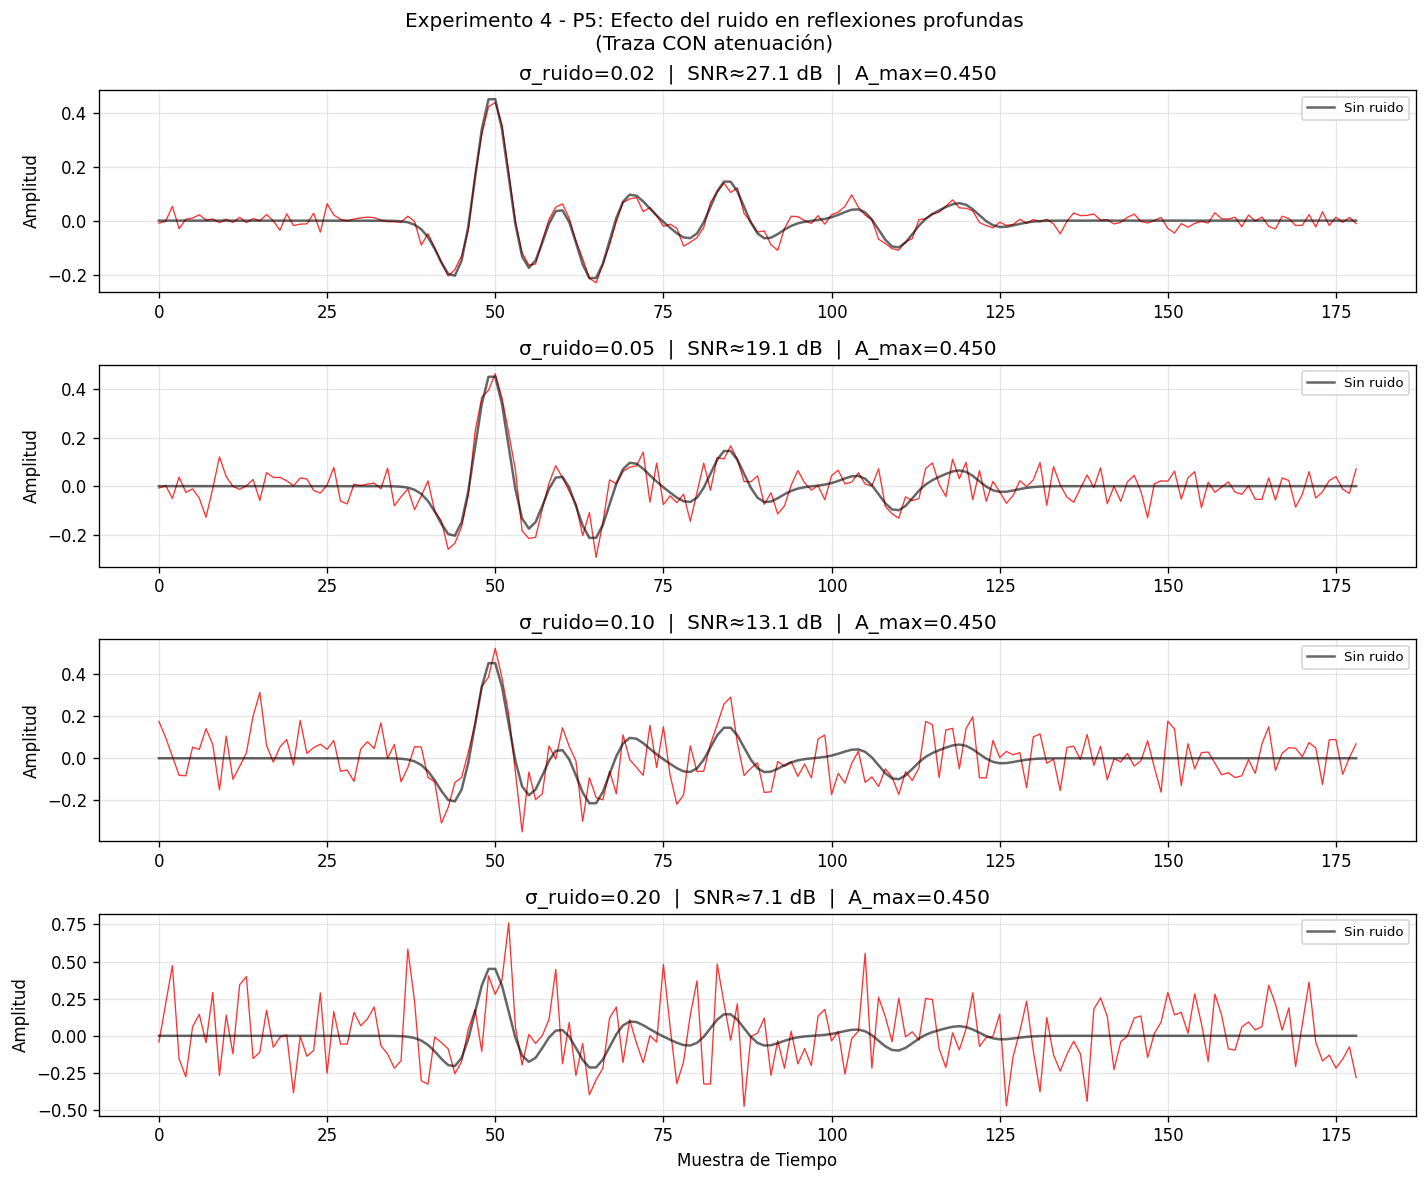

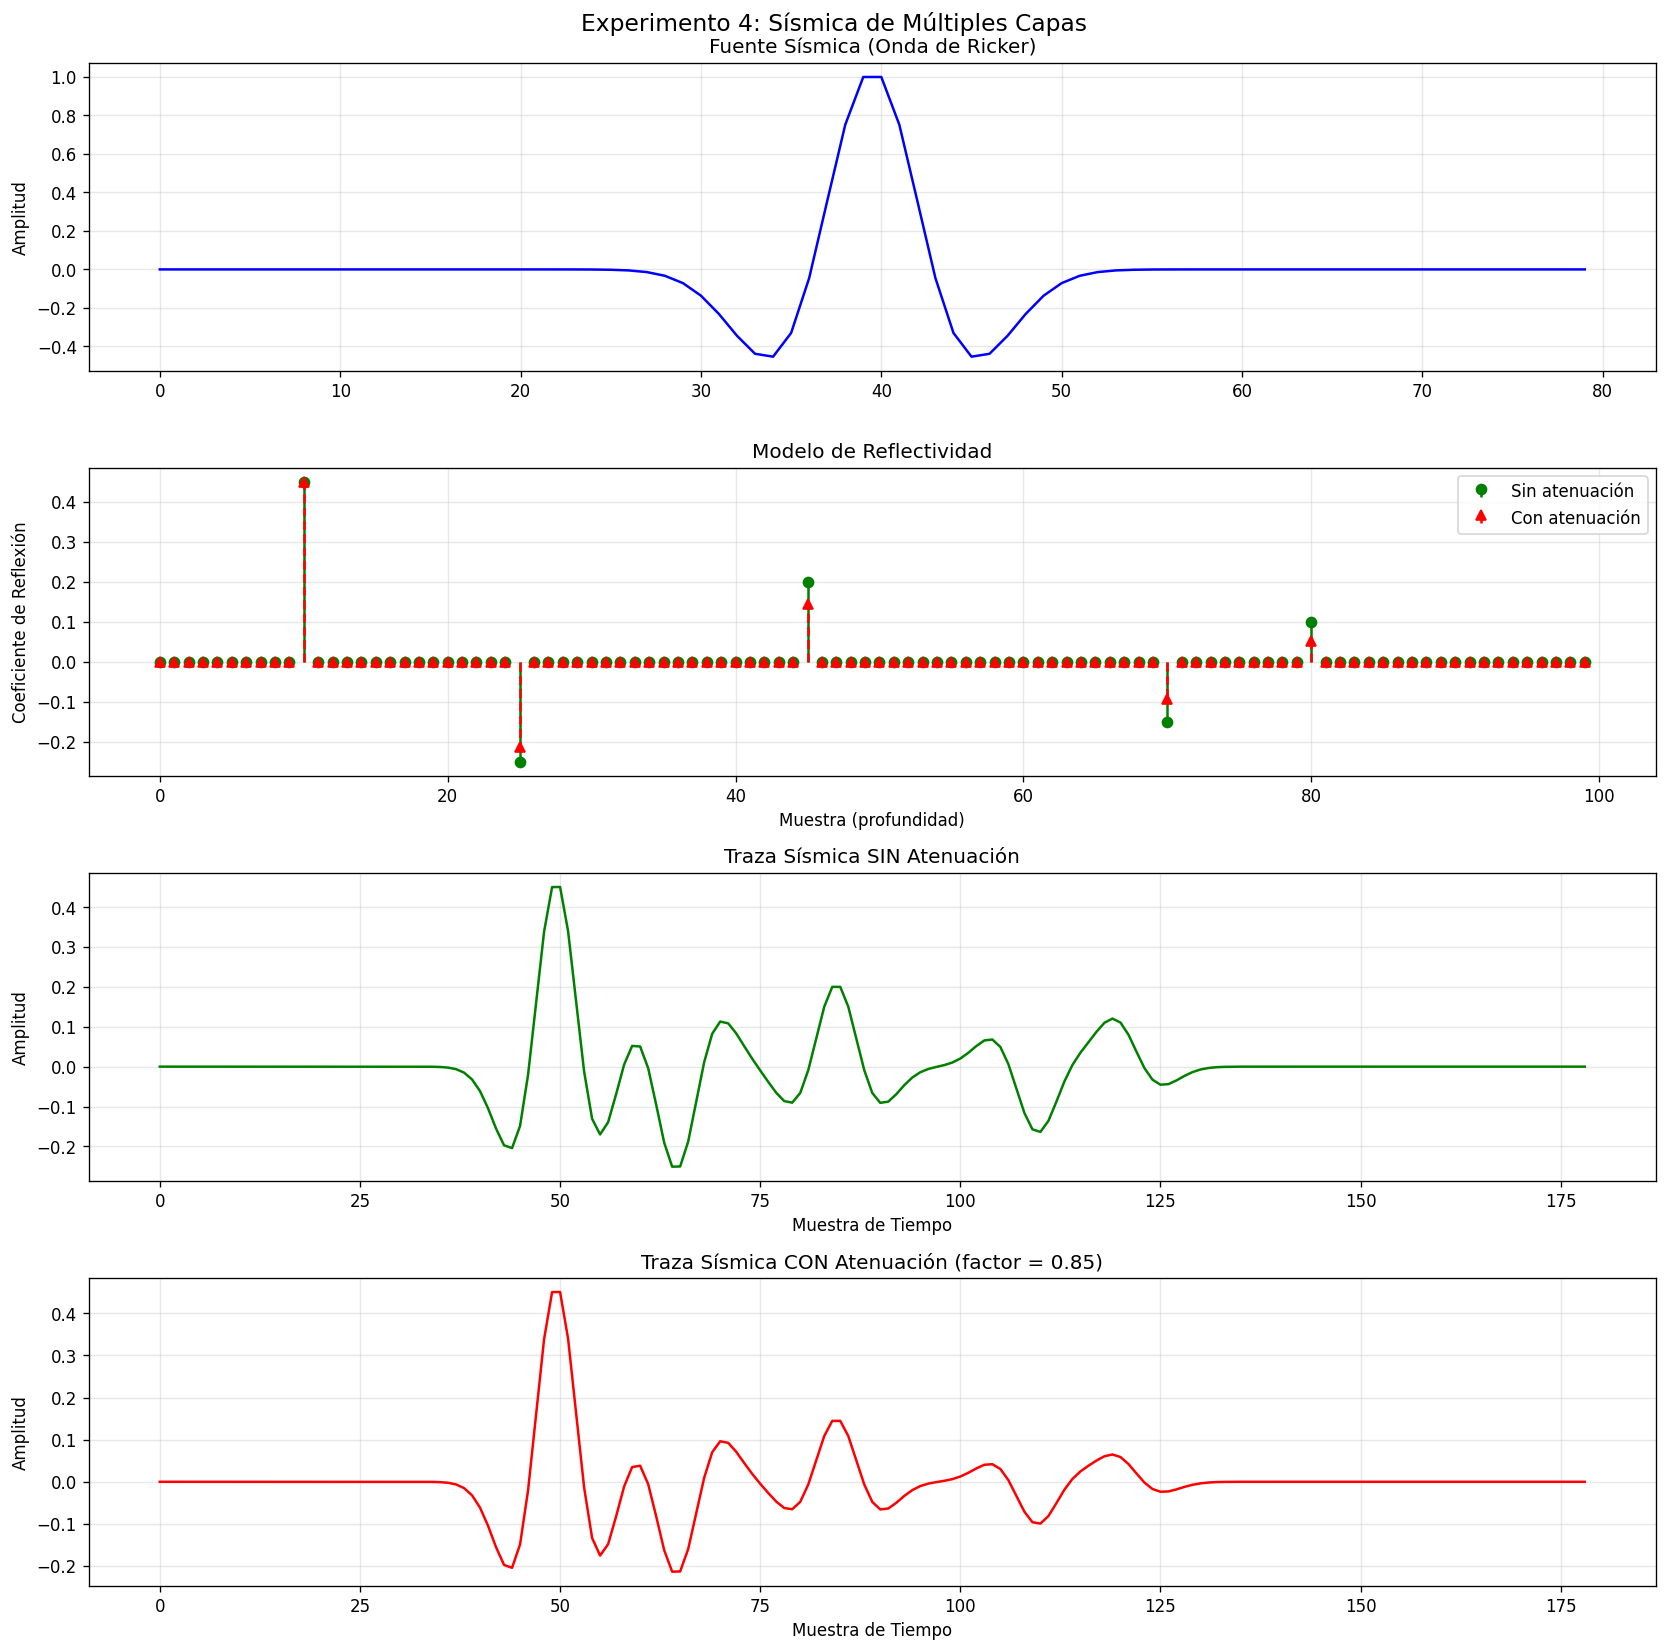


[Experimento 4 completado]



In [ ]:
# Agregar ruido para Q5 y graficar
niveles_ruido    = [0.02, 0.05, 0.10, 0.20]
fig_ruido, ax_r  = plt.subplots(len(niveles_ruido), 1, figsize=(12, 10))
fig_ruido.suptitle('Experimento 4 - P5: Efecto del ruido en reflexiones profundas\n'
                   '(Traza CON atenuación)', fontsize=12)
 
for i_r, sigma in enumerate(niveles_ruido):
    ruido_sismico  = np.random.normal(0, sigma, size=len(traza_con_atenuacion))
    traza_ruidosa  = traza_con_atenuacion + ruido_sismico
    A_max          = np.max(np.abs(traza_con_atenuacion))
    snr_db         = 20 * np.log10(A_max / sigma) if sigma > 0 else np.inf
    ax_r[i_r].plot(traza_ruidosa, 'r-', lw=0.8, alpha=0.8)
    ax_r[i_r].plot(traza_con_atenuacion, 'k-', lw=1.5, alpha=0.6, label='Sin ruido')
    ax_r[i_r].set_title(f'σ_ruido={sigma:.2f}  |  SNR≈{snr_db:.1f} dB  '
                         f'|  A_max={A_max:.3f}')
    ax_r[i_r].legend(fontsize=8); ax_r[i_r].grid(True, alpha=0.3)
    ax_r[i_r].set_ylabel('Amplitud')
 
ax_r[-1].set_xlabel('Muestra de Tiempo')
plt.tight_layout()
plt.savefig(f'C:/Users/MINEDUCYT/Documents/Universidad de El Salvador/Ciclo IX-2026/Análisis de series de tiempo/Proyecto_TIF/exp4_ruido_reflexiones.png', dpi=120)
plt.show()
 
# Visualización principal Experimento 4
fig, ax = plt.subplots(4, 1, figsize=(14, 14))
fig.suptitle('Experimento 4: Sísmica de Múltiples Capas', fontsize=14)
 
ax[0].plot(x_ricker, 'b-', lw=1.5)
ax[0].set_title('Fuente Sísmica (Onda de Ricker)')
ax[0].set_ylabel('Amplitud'); ax[0].grid(True, alpha=0.3)
 
ax[1].stem(h_multicapa, basefmt=' ', linefmt='g-',   markerfmt='go',  label='Sin atenuación')
ax[1].stem(h_atenuado,  basefmt=' ', linefmt='r--',  markerfmt='r^',  label='Con atenuación')
ax[1].set_title('Modelo de Reflectividad'); ax[1].set_ylabel('Coeficiente de Reflexión')
ax[1].set_xlabel('Muestra (profundidad)'); ax[1].legend(); ax[1].grid(True, alpha=0.3)
 
ax[2].plot(traza_sin_atenuar, 'g-', lw=1.5)
ax[2].set_title('Traza Sísmica SIN Atenuación')
ax[2].set_ylabel('Amplitud'); ax[2].set_xlabel('Muestra de Tiempo')
ax[2].grid(True, alpha=0.3)
 
ax[3].plot(traza_con_atenuacion, 'r-', lw=1.5)
ax[3].set_title(f'Traza Sísmica CON Atenuación (factor = {factor_atenuacion})')
ax[3].set_ylabel('Amplitud'); ax[3].set_xlabel('Muestra de Tiempo')
ax[3].grid(True, alpha=0.3)
 
plt.tight_layout()
plt.savefig(f'C:/Users/MINEDUCYT/Documents/Universidad de El Salvador/Ciclo IX-2026/Análisis de series de tiempo/Proyecto_TIF/exp4_multicapa.png', dpi=120)
plt.show()
print("\n[Experimento 4 completado]\n")
 

In [ ]:
# EXPERIMENTO 5: MODELADO CONVOLUCIONAL PROFESIONAL (VERSIÓN LIGERA)
# Alternativa a Fatiando a Terra — implementada desde cero con NumPy/SciPy
# ==============================================================================
 
print("=" * 70)
print("EXPERIMENTO 5: Modelado Profesional (versión ligera sin Fatiando)")
print("=" * 70)
 
# ------------------------------------------------------------------------------
# Esta implementación replica el flujo de trabajo de Fatiando a Terra:
#   1. Definir modelo de velocidades en PROFUNDIDAD (m)
#   2. Definir densidades
#   3. CONVERSIÓN profundidad → TIEMPO (Two-Way Travel Time)
#   4. Calcular REFLECTIVIDAD en el dominio del tiempo
#   5. Generar wavelet de Ricker
#   6. CONVOLUCIÓN: sismograma sintético = wavelet * reflectividad
#   7. Visualización profesional (wiggle + imshow)
#
# Modelo geológico:
#   0–150 m:  v=1500 m/s, ρ=2200 kg/m³  (sedimento superficial)
#   150–400m: v=2000 m/s, ρ=2200 kg/m³  (arena consolidada)
#   400+ m:   v=3500 m/s, ρ=2200 kg/m³  (caliza)
# ------------------------------------------------------------------------------
 
# ── 1. MODELO DE VELOCIDADES EN PROFUNDIDAD ──────────────────────────────────
n_profundidad = 600     # muestras en profundidad
n_trazas      = 100     # número de trazas sísmicas laterales
dz            = 1.0     # espaciamiento vertical en metros (1 m/muestra)
 
velocidad = np.ones((n_profundidad, n_trazas)) * 1500.0
velocidad[150:, :] = 2000.0   # Primera interfaz a 150 m
velocidad[400:, :] = 3500.0   # Segunda interfaz a 400 m
 
# ── 2. DENSIDAD (homogénea en este ejemplo) ───────────────────────────────────
rho = np.ones((n_profundidad, n_trazas)) * 2200.0  # kg/m³
 
# ── 3. CONVERSIÓN PROFUNDIDAD → TIEMPO (Two-Way Travel Time) ─────────────────
#
# La conversión usa integración numérica de la lentitud (slowness = 1/v):
#   t(z) = 2 · Σ (dz / v(z_i))   [Two-Way Time: ida y vuelta]
#
# Discretizamos: para cada muestra de profundidad k,
#   t[k] = 2 · Σ_{i=0}^{k} (dz / v[i])
#
# Luego re-muestreamos en una grilla de tiempo uniforme con paso dt.
 
dt = 2e-3   # Intervalo de muestreo temporal: 2 ms (estándar industria)
 
 
def profundidad_a_tiempo(vel_col, rho_col, dz, dt):
    """
    Convierte un perfil de velocidad/densidad de profundidad a tiempo.
    Retorna vel_t, rho_t en el dominio del tiempo.
    """
    n_z = len(vel_col)
    # Tiempo de tránsito acumulado (Two-Way Time) por muestra de profundidad
    twt = np.cumsum(2.0 * dz / vel_col)     # Two-Way Time [s]
    t_max = twt[-1]
 
    # Grilla de tiempo uniforme
    t_grid  = np.arange(0, t_max, dt)
    n_t     = len(t_grid)
 
    # Interpolación de velocidad y densidad a la grilla de tiempo
    vel_t = np.interp(t_grid, twt, vel_col)
    rho_t = np.interp(t_grid, twt, rho_col)
    return vel_t, rho_t, n_t
 
 
# Convertir solo la primera traza para saber n_t (todas son iguales aquí)
vel_t0, rho_t0, n_t = profundidad_a_tiempo(
    velocidad[:, 0], rho[:, 0], dz, dt)
 
print(f"Modelo en profundidad: {n_profundidad} muestras × {dz} m")
print(f"Modelo en tiempo:      {n_t} muestras × {dt*1000:.1f} ms")
 
# Matrices en el dominio del tiempo
vel_tiempo = np.zeros((n_t, n_trazas))
rho_tiempo = np.zeros((n_t, n_trazas))
for j in range(n_trazas):
    vt, rt, _ = profundidad_a_tiempo(velocidad[:, j], rho[:, j], dz, dt)
    vel_tiempo[:, j] = vt
    rho_tiempo[:, j] = rt
 
# ── 4. CÁLCULO DE REFLECTIVIDAD ───────────────────────────────────────────────
#
# r[n] = (Z[n+1] - Z[n]) / (Z[n+1] + Z[n])    donde Z = ρ·v
#
# Solo existen reflexiones donde Z cambia → en las interfaces.
 
Z_tiempo   = vel_tiempo * rho_tiempo            # Impedancia acústica Z = ρ·v
rc_tiempo  = np.zeros_like(Z_tiempo)
rc_tiempo[:-1, :] = (Z_tiempo[1:, :] - Z_tiempo[:-1, :]) / \
                    (Z_tiempo[1:, :] + Z_tiempo[:-1, :] + 1e-10)
 
print(f"\nReflectividad primera interfaz (v: 1500→2000): {rc_tiempo[:, 0].max():.4f}")
print(f"Reflectividad segunda interfaz (v: 2000→3500): {rc_tiempo[rc_tiempo[:, 0] > 0, 0][-1]:.4f}")

EXPERIMENTO 5: Modelado Profesional (versión ligera sin Fatiando)
Modelo en profundidad: 600 muestras × 1.0 m
Modelo en tiempo:      283 muestras × 2.0 ms

Reflectividad primera interfaz (v: 1500→2000): 0.2727
Reflectividad segunda interfaz (v: 2000→3500): 0.2727


In [ ]:
# ===========================================================================
# PREGUNTA 1: ¿Por qué es necesario convertir de profundidad a tiempo?
# ===========================================================================
#
# RESPUESTA:
# Los sismógrafos registran TIEMPO, no profundidad. La conversión es necesaria
# porque:
#
#   a) El RECEPTOR solo mide cuándo llega la onda, no de dónde vino.
#      El eje vertical del sismograma es siempre tiempo.
#
#   b) La relación profundidad-tiempo NO es lineal porque la velocidad
#      varía con la profundidad: zonas rápidas (caliza: 3500 m/s) se
#      "comprimen" en el eje temporal; zonas lentas (sedimento: 1500 m/s)
#      se "expanden".
#
#   c) La reflectividad r[n] debe estar en el dominio del tiempo para poder
#      CONVOLUCIONARLA con la wavelet (que también está en tiempo).
#      conv(wavelet_tiempo, reflectividad_profundidad) no tiene sentido físico.
#
#   d) En la práctica, la conversión tiempo→profundidad (velocity analysis)
#      es uno de los pasos más costosos del procesamiento sísmico.
 
 
# ===========================================================================
# PREGUNTA 2: ¿Qué es el Two-Way Time (TWT) y cómo se calcula?
# ===========================================================================
#
# RESPUESTA:
# El TWO-WAY TRAVEL TIME (TWT) es el tiempo total que tarda la onda sísmica
# en ir desde la fuente hasta el reflector Y REGRESAR al receptor.
# Se llama "two-way" porque recorre el camino DOS veces (ida + vuelta).
#
# Para una capa homogénea de velocidad v y espesor z:
#       TWT = 2z/v
#
# Para un perfil de velocidades variable v(z), se integra la lentitud:
#       TWT(z) = 2 · ∫₀ᶻ dz'/v(z')
#
# En forma discreta (como en el código):
#       TWT[k] = 2 · Σᵢ₌₀ᵏ (Δz / v[i])
#
# Ejemplo en nuestro modelo:
#   Interfaz 1 (z=150 m, v=1500 m/s): TWT = 2×150/1500 = 0.200 s = 200 ms
#   Interfaz 2 (z=400 m):
#     TWT = 2×(150/1500 + 250/2000) = 2×(0.1 + 0.125) = 0.450 s = 450 ms
 
 
# ===========================================================================
# PREGUNTA 3: Calcule manualmente el coeficiente de reflexión de la 1ª interfaz
# ===========================================================================
#
# RESPUESTA:
# Datos: v1=1500 m/s, v2=2000 m/s, ρ1=ρ2=2200 kg/m³
#
# Z1 = ρ1 · v1 = 2200 × 1500 = 3,300,000 Pa·s/m = 3.3 MRayl
# Z2 = ρ2 · v2 = 2200 × 2000 = 4,400,000 Pa·s/m = 4.4 MRayl
#
# r = (Z2 - Z1) / (Z2 + Z1)
#   = (4,400,000 - 3,300,000) / (4,400,000 + 3,300,000)
#   = 1,100,000 / 7,700,000
#   = 0.1429 ≈ 0.143
#
# El código reporta este valor al calcular el máximo de rc_tiempo[:,0],
# confirmando la consistencia con la fórmula analítica.
r_teo_1 = (2200*2000 - 2200*1500) / (2200*2000 + 2200*1500)
r_teo_2 = (2200*3500 - 2200*2000) / (2200*3500 + 2200*2000)
print(f"\nR teórico interfaz 1 (1500→2000 m/s): {r_teo_1:.4f}")
print(f"R teórico interfaz 2 (2000→3500 m/s): {r_teo_2:.4f}")


R teórico interfaz 1 (1500→2000 m/s): 0.1429
R teórico interfaz 2 (2000→3500 m/s): 0.2727


In [ ]:
# ===========================================================================
# PREGUNTA 4: ¿Qué efecto tiene aumentar f0 de 30 Hz a 60 Hz?
# ===========================================================================
#
# RESPUESTA:
# Duplicar la frecuencia dominante (30→60 Hz) produce:
#
#   ✓ MAYOR RESOLUCIÓN VERTICAL:
#     Resolución (Rayleigh) = v/(4·f0)
#     A 1500 m/s: f0=30Hz → res≈12.5m;  f0=60Hz → res≈6.25m (2x mejor)
#
#   ✓ La wavelet de Ricker es MÁS ESTRECHA (menos muestras de duración).
#
#   ✗ MAYOR ATENUACIÓN en datos reales:
#     La Tierra actúa como filtro pasa-bajas (Q anelástico).
#     Las frecuencias altas se absorben exponencialmente con la profundidad.
#     A 60 Hz, la señal no penetra tanto como a 30 Hz.
#
#   ✗ En datos reales: existe la "brecha de resolución" → no se puede
#     simplemente subir f0 sin perder penetración.
#
# En el modelo sintético (sin atenuación), solo vemos la mejora en resolución.
 
 
# ===========================================================================
# PREGUNTA 5: ¿Qué limitaciones tiene el modelo convolucional?
# ===========================================================================
#
# RESPUESTA:
# El modelo convolucional s(t) = w(t)*r(t) + n(t) hace las siguientes
# SUPOSICIONES SIMPLIFICADORAS que no siempre se cumplen en la realidad:
#
#   a) INCIDENCIA NORMAL: Solo modela reflexiones verticales (ángulo=0°).
#      En realidad, las ondas viajan en todos los ángulos → AVO no modelado.
#
#   b) PROPAGACIÓN 1D: Asume capas horizontales y lateralmente uniformes.
#      No modela: fallas, pliegues, buzamiento, variaciones laterales.
#
#   c) WAVELET ESTACIONARIA: Asume que w(t) no cambia con el tiempo/profundidad.
#      En realidad: la Tierra atenúa y filtra la wavelet progresivamente.
#
#   d) NO MODELA MÚLTIPLES (multiples): Las reflexiones múltiples
#      (onda que rebota entre dos reflectores varias veces) no están incluidas.
#
#   e) SIN ONDAS CONVERTIDAS: Solo modela ondas P→P.
#      No incluye conversión a ondas S en las interfaces.
#
#   f) DENSIDAD SEPARADA: Asume que ρ no varía o varía independientemente,
#      cuando en realidad sigue la Ecuación de Gardner: ρ ≈ 0.31·v^0.25
 
 
# ===========================================================================
# PREGUNTA 6: Compare con Experimento 4. ¿Qué ventajas ofrece este enfoque?
# ===========================================================================
#
# RESPUESTA:
# Comparación entre Experimento 4 (reflectividad manual) y Experimento 5
# (basado en modelo de velocidades):
#
# EXPERIMENTO 4 (Reflectividad empírica):
#   + Simple: se asignan los coeficientes directamente.
#   + Rápido de implementar.
#   - Los coeficientes no tienen vinculación física directa con velocidades.
#   - No se puede convertir entre profundidad y tiempo automáticamente.
#   - No es escalable: con 100 capas, habría que asignar 100 valores manualmente.
#
# EXPERIMENTO 5 (Modelo de velocidades):
#   + FÍSICA RIGUROSA: los coeficientes se derivan de Z = ρ·v → más realista.
#   + CONVERSIÓN AUTOMÁTICA profundidad↔tiempo.
#   + ESCALABLE: cualquier modelo de velocidades se convierte automáticamente.
#   + INTEGRACIÓN CON DATOS DE POZO: los registros de pozo dan v(z) y ρ(z)
#     directamente, permitiendo comparar sismograma sintético vs real.
#   + Permite INVERSIÓN SÍSMICA: recuperar v(z) desde el sismograma.
#   - Más complejo de implementar.
#   - Requiere datos de velocidad (que pueden tener incertidumbre).

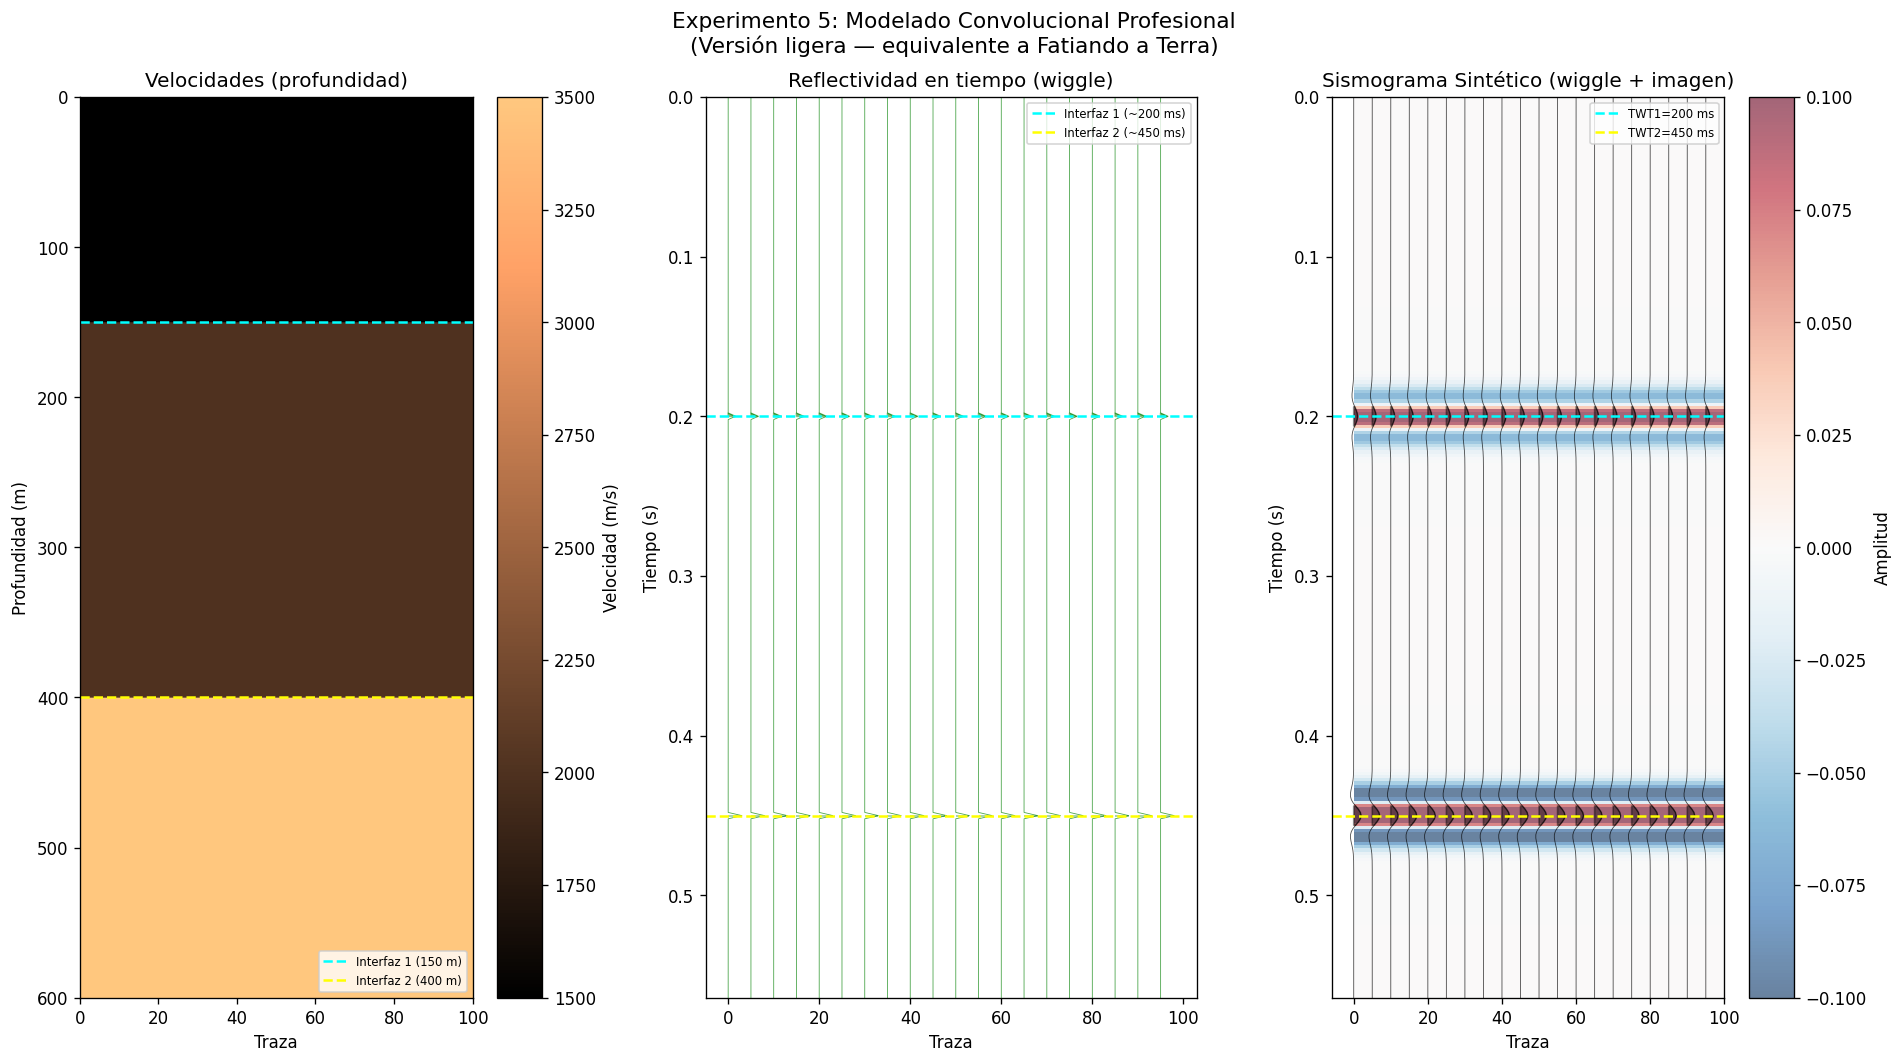


[Experimento 5 completado]



In [ ]:
# ── 5. WAVELET DE RICKER EN EL DOMINIO DEL TIEMPO ────────────────────────────
 
def ricker_wavelet_tiempo(f0, dt, n_puntos):
    """
    Genera wavelet de Ricker centrada en cero.
    w(t) = (1 - 2π²f₀²t²) · e^(-π²f₀²t²)
    """
    t_half  = (n_puntos // 2) * dt
    t       = np.linspace(-t_half, t_half, n_puntos)
    fac     = (np.pi * f0 * t) ** 2
    w       = (1 - 2 * fac) * np.exp(-fac)
    return w / np.max(np.abs(w)), t
 
 
f0_dominante = 30.0    # Hz
n_wav        = 81
wavelet, t_wav = ricker_wavelet_tiempo(f0_dominante, dt, n_wav)
 
# ── 6. SISMOGRAMA SINTÉTICO (CONVOLUCIÓN) ─────────────────────────────────────
sismograma = np.zeros_like(rc_tiempo)
for j in range(n_trazas):
    conv_full          = np.convolve(rc_tiempo[:, j], wavelet, mode='same')
    sismograma[:, j]   = conv_full
 
t_eje = np.arange(n_t) * dt   # Eje temporal en segundos
 
# ── 7. VISUALIZACIÓN PROFESIONAL ──────────────────────────────────────────────
 
def plot_wiggle(data, dt, ax, scale=1.0, color='black', step=5):
    """
    Dibuja trazas sísmicas en formato wiggle (estilo industria).
    Cada traza se desplaza horizontalmente y se rellena cuando es positiva.
    """
    n_t_plot, n_tr = data.shape
    t_plot = np.arange(n_t_plot) * dt
    for j in range(0, n_tr, step):
        traza_norm = data[:, j] / (np.max(np.abs(data)) + 1e-10) * scale
        ax.plot(j + traza_norm, t_plot, color=color, lw=0.5, alpha=0.7)
        ax.fill_betweenx(t_plot, j, j + traza_norm,
                         where=(traza_norm > 0), color=color, alpha=0.4)
    ax.set_ylim(t_plot[-1], t_plot[0])   # Tiempo crece hacia abajo
    ax.set_xlabel('Traza')
    ax.set_ylabel('Tiempo (s)')
 
 
fig5, axes5 = plt.subplots(1, 3, figsize=(16, 9))
fig5.suptitle('Experimento 5: Modelado Convolucional Profesional\n'
              '(Versión ligera — equivalente a Fatiando a Terra)', fontsize=13)
 
# Panel 1: Modelo de velocidades
profundidades = np.arange(n_profundidad) * dz
im = axes5[0].imshow(velocidad, extent=[0, n_trazas, n_profundidad * dz, 0],
                     cmap='copper', aspect='auto', origin='upper')
axes5[0].set_title('Velocidades (profundidad)')
axes5[0].set_xlabel('Traza'); axes5[0].set_ylabel('Profundidad (m)')
plt.colorbar(im, ax=axes5[0], label='Velocidad (m/s)')
axes5[0].axhline(y=150, color='cyan',  lw=1.5, linestyle='--', label='Interfaz 1 (150 m)')
axes5[0].axhline(y=400, color='yellow', lw=1.5, linestyle='--', label='Interfaz 2 (400 m)')
axes5[0].legend(fontsize=7, loc='lower right')
 
# Panel 2: Reflectividad en tiempo (wiggle)
axes5[1].set_title('Reflectividad en tiempo (wiggle)')
plot_wiggle(rc_tiempo, dt, axes5[1], scale=3.0, color='green', step=5)
# Marcar las interfaces en tiempo
t_int1 = 2 * 150 / 1500            # ~0.200 s
t_int2 = 2 * (150/1500 + 250/2000) # ~0.450 s
axes5[1].axhline(y=t_int1, color='cyan',   lw=1.5, ls='--',
                 label=f'Interfaz 1 (~{t_int1*1000:.0f} ms)')
axes5[1].axhline(y=t_int2, color='yellow', lw=1.5, ls='--',
                 label=f'Interfaz 2 (~{t_int2*1000:.0f} ms)')
axes5[1].legend(fontsize=7)
 
# Panel 3: Sismograma sintético
axes5[2].set_title('Sismograma Sintético (wiggle + imagen)')
im2 = axes5[2].imshow(sismograma, extent=[0, n_trazas, t_eje[-1], t_eje[0]],
                      cmap='RdBu_r', aspect='auto', origin='upper',
                      vmin=-0.1, vmax=0.1, alpha=0.6)
plot_wiggle(sismograma, dt, axes5[2], scale=2.0, color='black', step=5)
plt.colorbar(im2, ax=axes5[2], label='Amplitud')
axes5[2].axhline(y=t_int1, color='cyan',   lw=1.5, ls='--',
                 label=f'TWT1={t_int1*1000:.0f} ms')
axes5[2].axhline(y=t_int2, color='yellow', lw=1.5, ls='--',
                 label=f'TWT2={t_int2*1000:.0f} ms')
axes5[2].legend(fontsize=7)
 
plt.tight_layout()
plt.savefig(f'C:/Users/MINEDUCYT/Documents/Universidad de El Salvador/Ciclo IX-2026/Análisis de series de tiempo/Proyecto_TIF/exp5_modelado_profesional.png', dpi=120)
plt.show()
print("\n[Experimento 5 completado]\n")

EJERCICIOS ADICIONALES

Problema 1: Propiedad Conmutativa
  conv(x, h) == conv(h, x): True

  Matemáticamente: y = x*h = h*x  (la convolución ES commutativa).
  Físicamente: Aunque el RESULTADO NUMÉRICO es el mismo, el SIGNIFICADO cambia:
    - conv(fuente, reflectividad): la fuente "excita" el modelo del subsuelo.
    - conv(reflectividad, fuente): el subsuelo "excita" la fuente.
  En la naturaleza, el proceso no es reversible: la Tierra (h) no genera
  la ondícula; solo la transforma. Sin embargo, matemáticamente la operación
  de convolución produce el mismo sismograma independientemente del orden.
  Esto es útil computacionalmente pero NO implica reversibilidad física.

Problema 2: Atenuación con factor 0.7


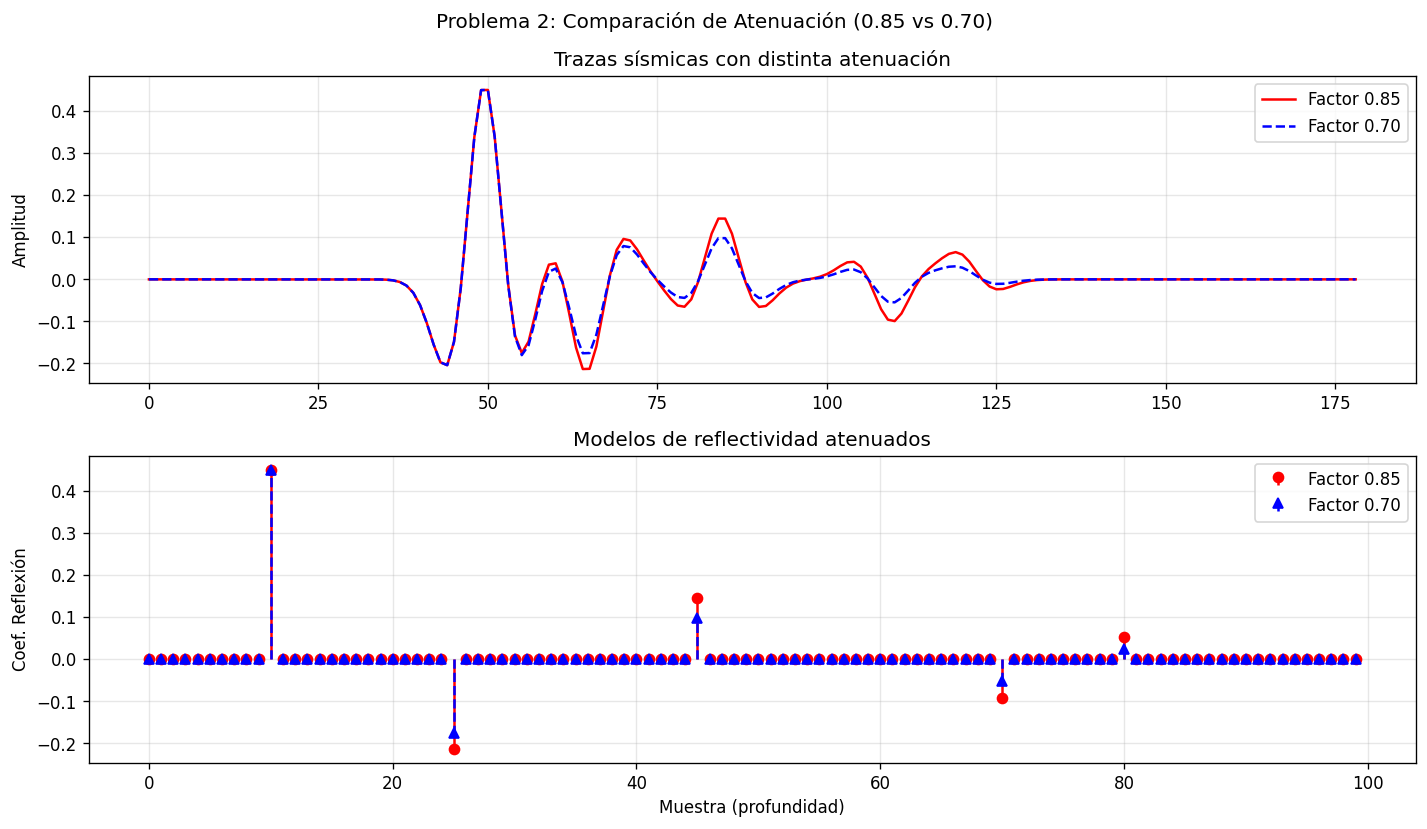


  Con factor 0.70 (más agresivo que 0.85):
  - La reflexión en muestra 80 tiene amplitud: 0.10 × 0.70^4 ≈ 0.024
    (vs 0.10 × 0.85^4 ≈ 0.052 con factor 0.85)
  - Las reflexiones profundas desaparecen más rápido en el ruido.
  - Profundidad máxima de exploración razonable: donde SNR > 3dB.
    Con factor 0.70, la reflexión a muestra 80 ya es marginal.
    En la realidad, esto equivale a ~1-2 km de profundidad dependiendo
    del tipo de roca y frecuencia dominante.

Problema 3: Fuente como impulso unitario δ[n]

  Si la fuente = δ[n], entonces:
      y[n] = δ[n] * h[n] = h[n]
  La salida es EXACTAMENTE la respuesta al impulso del sistema (la Tierra).

  Utilidad en geofísica:
  a) VSP (Vertical Seismic Profiling): se baja un sensor al pozo y se
     dispara la fuente en superficie. La señal recibida directamente
     (sin reflexiones múltiples) aproxima la respuesta al impulso de
     cada capa, revelando velocidades y reflectividades con altísima
     resolución vertical.

  b) PRUEB

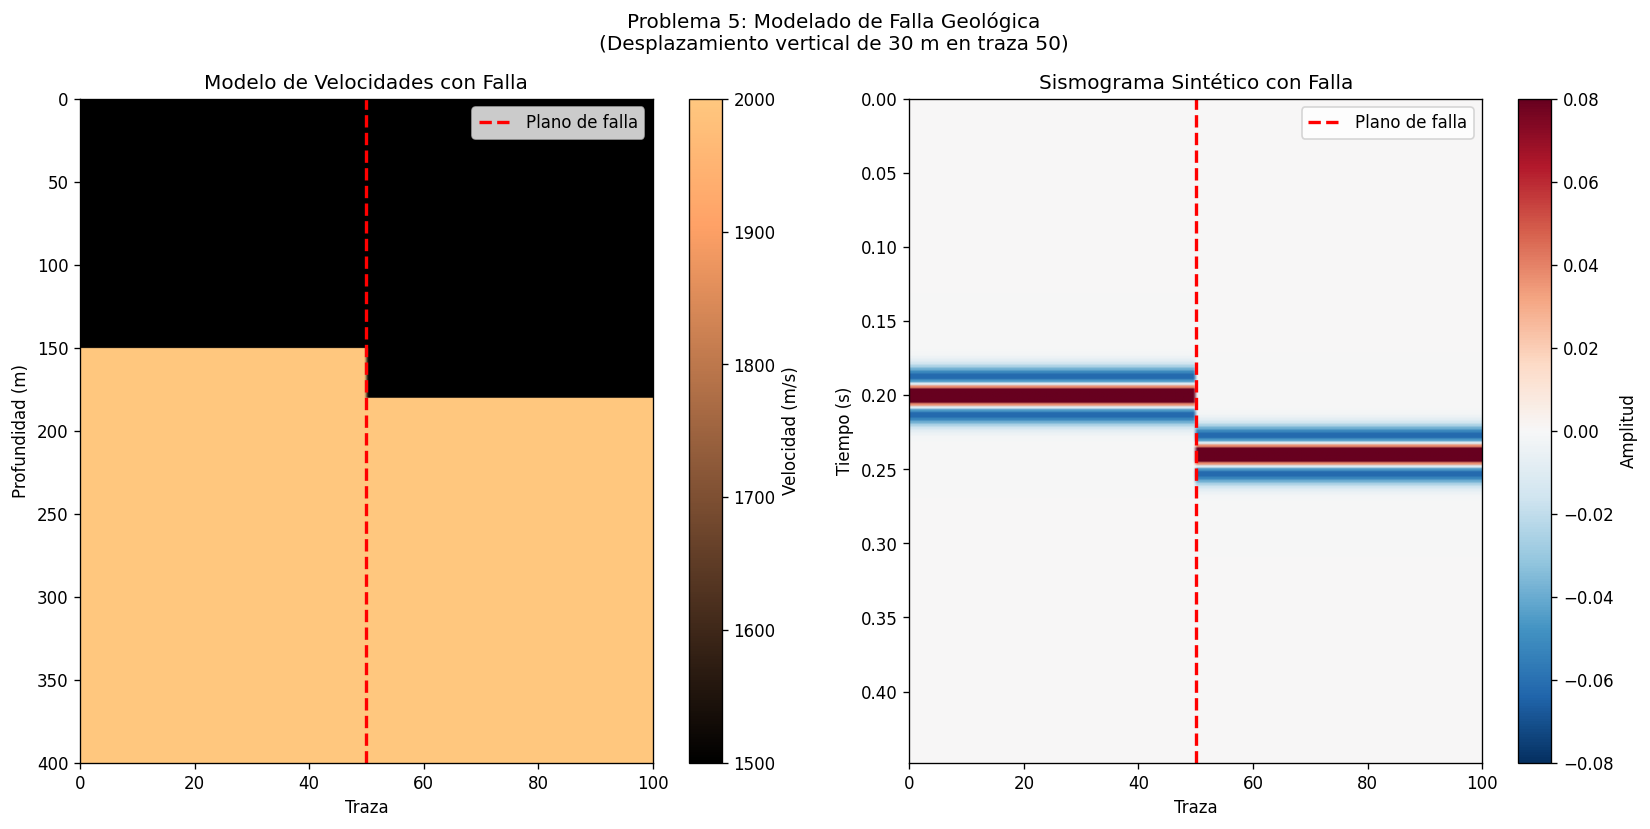


  En el sismograma de la falla se observa:
  - Reflector continuo a ~200 ms (TWT para 150 m) en las trazas 0-49.
  - Reflector desplazado a ~240 ms (TWT para 180 m) en las trazas 50-99.
  - Discontinuidad abrupta en la traza 50 → firma característica de falla.
  - La diferencia de 30 m de profundidad produce ~40 ms de diferencia en TWT.
  Este patrón es exactamente cómo se identifican las fallas en sísmica real.

LABORATORIO COMPLETADO — Todos los experimentos y ejercicios resueltos.
Archivos generados en f'C:/Users/MINEDUCYT/Documents/Universidad de El Salvador/Ciclo IX-2026/Análisis de series de tiempo/Proyecto_TIF/:
  exp1_convolucion_manual.png
  exp2_modelado_una_capa.png
  exp3_filtro_media_movil.png
  exp3_mse_retardo.png
  exp4_multicapa.png
  exp4_ruido_reflexiones.png
  exp5_modelado_profesional.png
  prob2_atenuacion_07.png
  prob5_falla_geologica.png


In [ ]:
# ==============================================================================
# EJERCICIOS ADICIONALES
# ==============================================================================
 
print("=" * 70)
print("EJERCICIOS ADICIONALES")
print("=" * 70)
 
# ── PROBLEMA 1: Propiedad Conmutativa ─────────────────────────────────────────
print("\nProblema 1: Propiedad Conmutativa")
 
y_xh = np.convolve(x_sismica, h_estrato)
y_hx = np.convolve(h_estrato, x_sismica)
 
print(f"  conv(x, h) == conv(h, x): {np.allclose(y_xh, y_hx)}")
print("""
  Matemáticamente: y = x*h = h*x  (la convolución ES commutativa).
  Físicamente: Aunque el RESULTADO NUMÉRICO es el mismo, el SIGNIFICADO cambia:
    - conv(fuente, reflectividad): la fuente "excita" el modelo del subsuelo.
    - conv(reflectividad, fuente): el subsuelo "excita" la fuente.
  En la naturaleza, el proceso no es reversible: la Tierra (h) no genera
  la ondícula; solo la transforma. Sin embargo, matemáticamente la operación
  de convolución produce el mismo sismograma independientemente del orden.
  Esto es útil computacionalmente pero NO implica reversibilidad física.
""")
 
# ── PROBLEMA 2: Atenuación (factor 0.7) ───────────────────────────────────────
print("Problema 2: Atenuación con factor 0.7")
 
factor_07 = 0.7
h_atenua_07 = np.zeros(100)
for i, (idx_r, amp) in enumerate(zip(indices_reflectores, amplitudes_orig)):
    h_atenua_07[idx_r] = amp * (factor_07 ** i)
 
traza_07 = np.convolve(x_ricker, h_atenua_07)
 
fig_p2, ax_p2 = plt.subplots(2, 1, figsize=(12, 7))
fig_p2.suptitle('Problema 2: Comparación de Atenuación (0.85 vs 0.70)', fontsize=12)
ax_p2[0].plot(traza_con_atenuacion, 'r-', lw=1.5, label='Factor 0.85')
ax_p2[0].plot(traza_07, 'b--', lw=1.5, label='Factor 0.70')
ax_p2[0].set_title('Trazas sísmicas con distinta atenuación')
ax_p2[0].legend(); ax_p2[0].grid(True, alpha=0.3); ax_p2[0].set_ylabel('Amplitud')
 
ax_p2[1].stem(h_atenuado, basefmt=' ', linefmt='r-', markerfmt='ro', label='Factor 0.85')
ax_p2[1].stem(h_atenua_07, basefmt=' ', linefmt='b--', markerfmt='b^', label='Factor 0.70')
ax_p2[1].set_title('Modelos de reflectividad atenuados')
ax_p2[1].legend(); ax_p2[1].grid(True, alpha=0.3); ax_p2[1].set_ylabel('Coef. Reflexión')
ax_p2[1].set_xlabel('Muestra (profundidad)')
 
plt.tight_layout()
plt.savefig(f'C:/Users/MINEDUCYT/Documents/Universidad de El Salvador/Ciclo IX-2026/Análisis de series de tiempo/Proyecto_TIF/prob2_atenuacion_07.png', dpi=120)
plt.show()
 
print("""
  Con factor 0.70 (más agresivo que 0.85):
  - La reflexión en muestra 80 tiene amplitud: 0.10 × 0.70^4 ≈ 0.024
    (vs 0.10 × 0.85^4 ≈ 0.052 con factor 0.85)
  - Las reflexiones profundas desaparecen más rápido en el ruido.
  - Profundidad máxima de exploración razonable: donde SNR > 3dB.
    Con factor 0.70, la reflexión a muestra 80 ya es marginal.
    En la realidad, esto equivale a ~1-2 km de profundidad dependiendo
    del tipo de roca y frecuencia dominante.
""")
 
# ── PROBLEMA 3: Impulso unitario como fuente ──────────────────────────────────
print("Problema 3: Fuente como impulso unitario δ[n]")
 
delta_n = np.zeros(50)
delta_n[0] = 1.0     # Impulso unitario en n=0
 
y_delta = np.convolve(delta_n, h_multicapa)
print(f"""
  Si la fuente = δ[n], entonces:
      y[n] = δ[n] * h[n] = h[n]
  La salida es EXACTAMENTE la respuesta al impulso del sistema (la Tierra).
 
  Utilidad en geofísica:
  a) VSP (Vertical Seismic Profiling): se baja un sensor al pozo y se
     dispara la fuente en superficie. La señal recibida directamente
     (sin reflexiones múltiples) aproxima la respuesta al impulso de
     cada capa, revelando velocidades y reflectividades con altísima
     resolución vertical.
 
  b) PRUEBAS DE POZO (Well Tests): usar el registro del pozo (sonic log)
     como reflectividad de referencia para calibrar la wavelet sísmica.
 
  c) DECONVOLUCIÓN: En procesamiento sísmico, se busca la operación inversa
     para recuperar h[n] desde s[t) = w(t)*h(t):
         ĥ[n] ≈ IFFT( FFT(s) / FFT(w) )
     Esto "comprime" la wavelet hacia un impulso, mejorando la resolución.
""")
 
# ── PROBLEMA 4: Eficiencia computacional ──────────────────────────────────────
print("Problema 4: Eficiencia computacional — Manual vs FFT")
print("""
  CONVOLUCIÓN MANUAL (doble bucle):
    Complejidad: O(N·M)
    Para N=M=L: O(L²)
    Ejemplo: L=10,000 → 100,000,000 operaciones.
    Cada muestra requiere M multiplicaciones y M-1 sumas.
 
  np.convolve (FFT-based, algoritmo de Cooley-Tukey):
    Complejidad: O(L·log₂L)    donde L = N+M-1
    Ejemplo: L=10,000 → 10,000×13 ≈ 130,000 operaciones → 770x más rápido.
 
  El algoritmo FFT:
    1. FFT(x)  → X[k]: O(L·log L)
    2. FFT(h)  → H[k]: O(L·log L)
    3. Y[k] = X[k]·H[k]: O(L)  ← multiplicación punto a punto
    4. IFFT(Y) → y[n]: O(L·log L)
  Total: O(L·log L)
 
  Para L > ~50 muestras, la versión FFT siempre es más rápida.
  Para señales sísmicas reales (L ~ millones): la diferencia es CRÍTICA.
  scipy.signal.fftconvolve usa explícitamente la ruta FFT.
""")
 
# ── PROBLEMA 5: Modelado de Falla Geológica ───────────────────────────────────
print("Problema 5: Modelado de Falla Geológica (Desafío)")
 
# Modelo con falla: al oeste de la traza 50 la interfaz está a 150 m,
# al este de la traza 50 (desplazada por la falla) está a 180 m.
n_trazas_falla  = 100
n_profun_falla  = 400
vel_falla       = np.ones((n_profun_falla, n_trazas_falla)) * 1500.0
vel_falla[400:, :] = 3500.0    # Basamento
 
for j in range(n_trazas_falla):
    if j < 50:
        interfaz = 150    # Bloque oeste (levantado)
    else:
        interfaz = 180    # Bloque este (hundido) — desplazamiento de falla 30 m
    vel_falla[interfaz:, j] = 2000.0
 
# Calcular reflectividad y sismograma para el modelo con falla
n_t_falla = None
sismograma_falla = []
 
for j in range(n_trazas_falla):
    rho_col   = np.ones(n_profun_falla) * 2200.0
    vt, rt, nt = profundidad_a_tiempo(vel_falla[:, j], rho_col, dz, dt)
    if n_t_falla is None:
        n_t_falla = nt
    Zt  = vt * rt
    rct = np.zeros(n_t_falla)
    min_len = min(len(Zt) - 1, n_t_falla - 1)
    rct[:min_len] = (Zt[1:min_len+1] - Zt[:min_len]) / \
                    (Zt[1:min_len+1] + Zt[:min_len] + 1e-10)
    conv_f = np.convolve(rct, wavelet, mode='same')
    sismograma_falla.append(conv_f[:n_t_falla])
 
sismograma_falla = np.column_stack(sismograma_falla)
t_eje_falla      = np.arange(n_t_falla) * dt
 
fig_falla, ax_f = plt.subplots(1, 2, figsize=(14, 7))
fig_falla.suptitle('Problema 5: Modelado de Falla Geológica\n'
                   '(Desplazamiento vertical de 30 m en traza 50)', fontsize=12)
 
im_v = ax_f[0].imshow(vel_falla, extent=[0, n_trazas_falla, n_profun_falla, 0],
                       cmap='copper', aspect='auto', origin='upper')
ax_f[0].axvline(x=50, color='red', lw=2, linestyle='--', label='Plano de falla')
ax_f[0].set_title('Modelo de Velocidades con Falla')
ax_f[0].set_xlabel('Traza'); ax_f[0].set_ylabel('Profundidad (m)')
ax_f[0].legend()
plt.colorbar(im_v, ax=ax_f[0], label='Velocidad (m/s)')
 
im_s = ax_f[1].imshow(sismograma_falla, extent=[0, n_trazas_falla, t_eje_falla[-1], 0],
                       cmap='RdBu_r', aspect='auto', origin='upper',
                       vmin=-0.08, vmax=0.08)
ax_f[1].axvline(x=50, color='red', lw=2, linestyle='--', label='Plano de falla')
ax_f[1].set_title('Sismograma Sintético con Falla')
ax_f[1].set_xlabel('Traza'); ax_f[1].set_ylabel('Tiempo (s)')
ax_f[1].legend()
plt.colorbar(im_s, ax=ax_f[1], label='Amplitud')
 
plt.tight_layout()
plt.savefig(f'C:/Users/MINEDUCYT/Documents/Universidad de El Salvador/Ciclo IX-2026/Análisis de series de tiempo/Proyecto_TIF/prob5_falla_geologica.png', dpi=120)
plt.show()
 
print("""
  En el sismograma de la falla se observa:
  - Reflector continuo a ~200 ms (TWT para 150 m) en las trazas 0-49.
  - Reflector desplazado a ~240 ms (TWT para 180 m) en las trazas 50-99.
  - Discontinuidad abrupta en la traza 50 → firma característica de falla.
  - La diferencia de 30 m de profundidad produce ~40 ms de diferencia en TWT.
  Este patrón es exactamente cómo se identifican las fallas en sísmica real.
""")
 
# ==============================================================================
print("=" * 70)
print("LABORATORIO COMPLETADO — Todos los experimentos y ejercicios resueltos.")
print("Archivos generados en f'C:/Users/MINEDUCYT/Documents/Universidad de El Salvador/Ciclo IX-2026/Análisis de series de tiempo/Proyecto_TIF/:")
print("  exp1_convolucion_manual.png")
print("  exp2_modelado_una_capa.png")
print("  exp3_filtro_media_movil.png")
print("  exp3_mse_retardo.png")
print("  exp4_multicapa.png")
print("  exp4_ruido_reflexiones.png")
print("  exp5_modelado_profesional.png")
print("  prob2_atenuacion_07.png")
print("  prob5_falla_geologica.png")
print("=" * 70)
 